In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [4]:
df1 = pd.read_csv("all_data/btc_6years_binance.csv")
df2 = pd.read_csv("all_data/eth_6years_binance.csv")

In [5]:
df1.head()

,date,open,high,low,close,volume,quote_volume
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08


In [6]:
df2.head()

,date,open,high,low,close,volume,quote_volume
0,2020-03-22,132.63,137.13,121.10,122.32,1.055700e+06,1.359279e+08
1,2020-03-23,122.31,137.50,119.50,135.92,1.436796e+06,1.848516e+08
2,2020-03-24,135.89,143.36,132.20,138.42,1.244377e+06,1.711564e+08
3,2020-03-25,138.42,142.33,132.54,136.10,1.034249e+06,1.417953e+08
4,2020-03-26,136.11,139.74,133.26,138.40,7.510606e+05,1.019188e+08


In [7]:
df1.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume'], dtype='object')

In [8]:
df1.isna().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
quote_volume    0
dtype: int64

In [9]:
df1.duplicated(subset='date').sum()

np.int64(0)

In [10]:
df1['date']=pd.to_datetime(df1['date'])
df2['date']=pd.to_datetime(df2['date'])

In [11]:
df2.duplicated(subset='date').sum()

np.int64(0)

In [12]:
df1["type"]='BTC'

In [13]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC


In [14]:
df2["type"]='ETH'

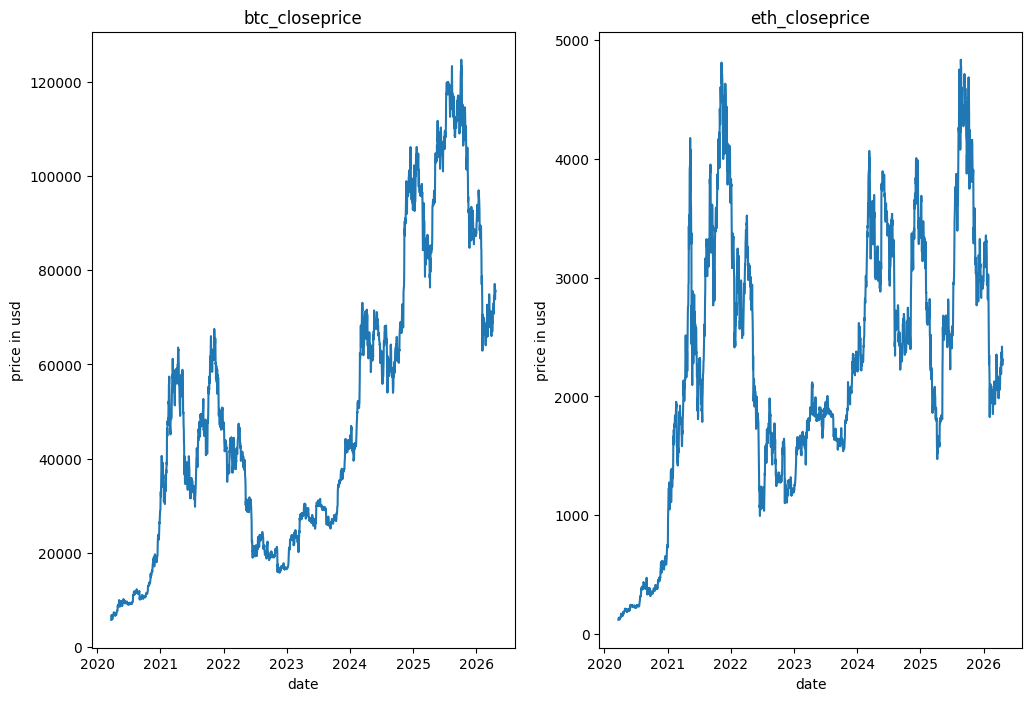

In [15]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df1,y='close')
plt.title("btc_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df2,y='close')
plt.title("eth_closeprice")
plt.ylabel("price in usd")
plt.show()

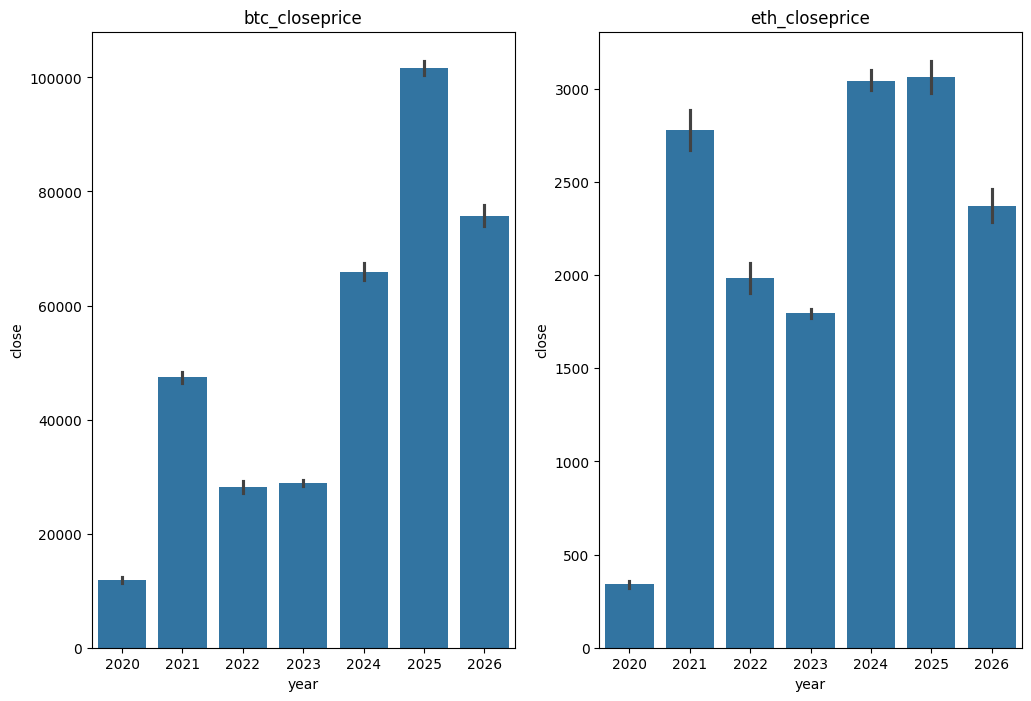

In [16]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["year"]=df1["date"].dt.year
sns.barplot(x='year',data=df1,y='close')
plt.title("btc_closeprice")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='close')
plt.title("eth_closeprice")
plt.show()

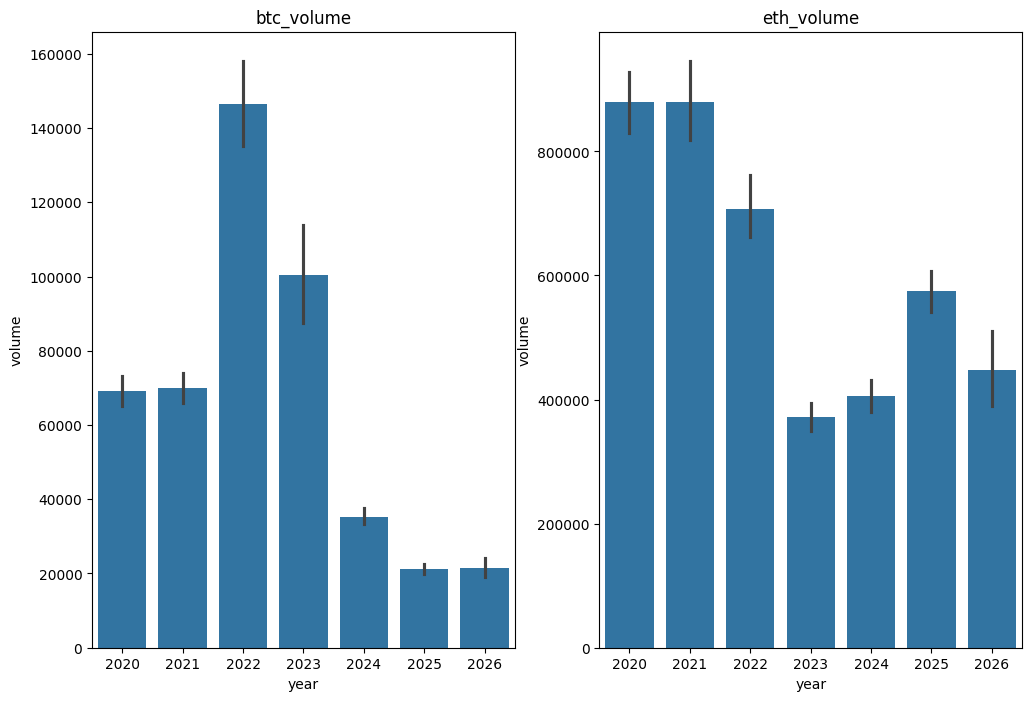

In [17]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
df1["year"]=df1["date"].dt.year
sns.barplot(x='year',data=df1,y='volume')
plt.title("btc_volume")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=df2,y='volume')
plt.title("eth_volume")
plt.show()

In [18]:
df1[['open','high','low','close','volume','quote_volume']].describe()

,open,high,low,close,volume,quote_volume
count,2222.000000,2222.000000,2222.000000,2222.000000,2222.000000,2.222000e+03
mean,49987.501494,51013.996170,48890.672061,50018.341688,71254.641062,2.388434e+09
std,30938.389501,31388.767875,30441.925055,30928.883465,86534.123024,1.961519e+09
min,5816.050000,6266.000000,5688.000000,5816.190000,3104.117220,2.066281e+08
25%,24882.612500,25904.390000,24447.500000,25031.235000,24087.480900,1.079470e+09
50%,42859.405000,43793.785000,41952.175000,42875.895000,43048.957711,1.861669e+09
75%,68248.837500,69500.000000,66820.227500,68260.462500,76683.583774,2.999123e+09
max,124658.540000,126199.630000,123084.000000,124658.540000,760705.362783,1.746531e+10


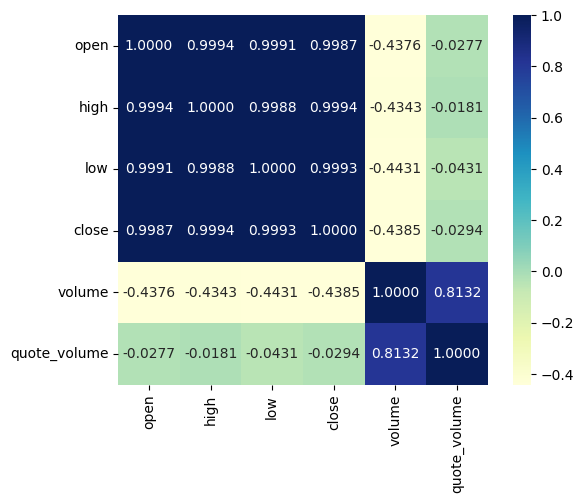

In [19]:
corr1=df1[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show() #as i predicted above the relation between volume and close price is negative as when volume is high thats mean closing price was low so alot of people buy

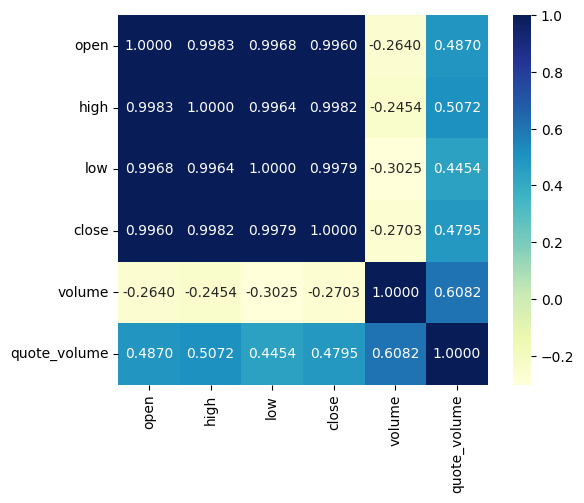

In [20]:
corr2=df2[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [21]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    btc_year = df1[df1['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])

    fig.update_layout(title=f'BTC Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    btc_year = df1[df1['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_year['date'],\n        open=btc_year['open'],\n        high=btc_year['high'],\n        low=btc_year['low'],\n        close=btc_year['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick Chart - {year}')\n    fig.show()"

In [22]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df1[(df1['date'].dt.year == year) & (df1['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])

    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    btc_filtered = df1[(df1['date'].dt.year == year) & (df1['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_filtered['date'],\n        open=btc_filtered['open'],\n        high=btc_filtered['high'],\n        low=btc_filtered['low'],\n        close=btc_filtered['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [23]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    eth_year = df2[df2['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=eth_year['date'],
        open=eth_year['open'],
        high=eth_year['high'],
        low=eth_year['low'],
        close=eth_year['close']
    )])

    fig.update_layout(title=f'ETH Candlestick Chart - {year}')
    fig.show() """

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    eth_year = df2[df2['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=eth_year['date'],\n        open=eth_year['open'],\n        high=eth_year['high'],\n        low=eth_year['low'],\n        close=eth_year['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick Chart - {year}')\n    fig.show() "

In [24]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    eth_filtered = df2[(df2['date'].dt.year == year) & (df2['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=eth_filtered['date'],
        open=eth_filtered['open'],
        high=eth_filtered['high'],
        low=eth_filtered['low'],
        close=eth_filtered['close']
    )])

    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    eth_filtered = df2[(df2['date'].dt.year == year) & (df2['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=eth_filtered['date'],\n        open=eth_filtered['open'],\n        high=eth_filtered['high'],\n        low=eth_filtered['low'],\n        close=eth_filtered['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [25]:
df1.drop(columns='year',inplace=True)
df2.drop(columns='year',inplace=True)

## Feature engeering

In [26]:
df1["candle_body"]=df1['close']-df1['open']
df2['candle_body']=df2['close']-df2['open']


In [27]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC,-370.85
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC,651.26
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC,279.47
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC,-67.26
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC,59.94


In [28]:
df1['high_low_range']=df1['high']-df1['low']
df2['high_low_range']=df2['high']-df2['low']

In [29]:
df1['MA_7']=df1['close'].rolling(window=7).mean()
df2['MA_7']=df2['close'].rolling(window=7).mean()

In [30]:
df1['MA_30']=df1['close'].rolling(window=30).mean()
df2['MA_30']=df2['close'].rolling(window=30).mean()

In [31]:
df1['moving_1d']=(df1['close']-df1['close'].shift(1))/df1['close'].shift(1) * 100
df2['moving_1d']=(df2['close']-df2['close'].shift(1))/df2['close'].shift(1) * 100

In [32]:
df1["volatility_7"] = df1["moving_1d"].rolling(window=7).std()
df2["volatility_7"] = df2["moving_1d"].rolling(window=7).std()

In [33]:
df1["volume_MA7"] = df1["volume"].rolling(window=7).mean()
df1["volumelast7"] = df1["volume"] / df1["volume_MA7"]
df2["volume_MA7"] = df2["volume"].rolling(window=7).mean()
df2["volumelast7"] = df2["volume"] / df2["volume_MA7"]

In [34]:
df1.drop(columns='volume_MA7',inplace=True)
df2.drop(columns='volume_MA7',inplace=True)

In [35]:
df1["rolling_mean_30"] = df1["close"].rolling(window=30).mean()
df1["rolling_std_30"]  = df1["close"].rolling(window=30).std()
df1["z_score"] = (df1["close"] - df1["rolling_mean_30"]) / df1["rolling_std_30"]

df2["rolling_mean_30"] = df2["close"].rolling(window=30).mean()
df2["rolling_std_30"]  = df2["close"].rolling(window=30).std()
df2["z_score"] = (df2["close"] - df2["rolling_mean_30"]) / df2["rolling_std_30"]

In [36]:
df1.drop(columns='rolling_mean_30',inplace=True)
df2.drop(columns='rolling_mean_30',inplace=True)
df1.drop(columns='rolling_std_30',inplace=True)
df2.drop(columns='rolling_std_30',inplace=True)

In [37]:
df1['tomorrow_close'] = df1['close'].shift(-1)
df1['tomorrow_return'] = (df1['tomorrow_close'] - df1['close']) / df1['close'] * 100


df2['tomorrow_close'] = df2['close'].shift(-1)
df2['tomorrow_return'] = (df2['tomorrow_close'] - df2['close']) / df2['close'] * 100

In [38]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-03-22,6187.04,6407.87,5734.01,5816.19,119115.990527,7.228957e+08,BTC,-370.85,673.86,NaN,NaN,NaN,NaN,NaN,NaN,6467.31,11.194958
1,2020-03-23,5816.05,6600.00,5688.00,6467.31,164674.215785,1.015526e+09,BTC,651.26,912.00,NaN,NaN,11.194958,NaN,NaN,NaN,6744.72,4.289419
2,2020-03-24,6465.25,6833.00,6371.33,6744.72,151138.009878,1.001891e+09,BTC,279.47,461.67,NaN,NaN,4.289419,NaN,NaN,NaN,6677.43,-0.997669
3,2020-03-25,6744.69,6957.96,6450.00,6677.43,132155.734989,8.802507e+08,BTC,-67.26,507.96,NaN,NaN,-0.997669,NaN,NaN,NaN,6737.36,0.897501
4,2020-03-26,6677.42,6780.00,6510.00,6737.36,83026.555211,5.525372e+08,BTC,59.94,270.00,NaN,NaN,0.897501,NaN,NaN,NaN,6359.11,-5.614217


In [39]:
df2.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-03-22,132.63,137.13,121.10,122.32,1.055700e+06,1.359279e+08,ETH,-10.31,16.03,NaN,NaN,NaN,NaN,NaN,NaN,135.92,11.118378
1,2020-03-23,122.31,137.50,119.50,135.92,1.436796e+06,1.848516e+08,ETH,13.61,18.00,NaN,NaN,11.118378,NaN,NaN,NaN,138.42,1.839317
2,2020-03-24,135.89,143.36,132.20,138.42,1.244377e+06,1.711564e+08,ETH,2.53,11.16,NaN,NaN,1.839317,NaN,NaN,NaN,136.10,-1.676058
3,2020-03-25,138.42,142.33,132.54,136.10,1.034249e+06,1.417953e+08,ETH,-2.32,9.79,NaN,NaN,-1.676058,NaN,NaN,NaN,138.40,1.689934
4,2020-03-26,136.11,139.74,133.26,138.40,7.510606e+05,1.019188e+08,ETH,2.29,6.48,NaN,NaN,1.689934,NaN,NaN,NaN,131.33,-5.108382


In [40]:
from scipy.stats import skew, kurtosis
df1 = df1.dropna(subset=['tomorrow_return'])
skew2=skew(df1['tomorrow_return'])
print(skew2)

df2 = df2.dropna(subset=['tomorrow_return'])
skew21=skew(df2['tomorrow_return'])
print(skew21)

kurtosis1=kurtosis(df1['tomorrow_return'])
kurtosis2=kurtosis(df2['tomorrow_return'])
kurtosis1,kurtosis2

0.19254174942586344
0.24196043268334025


(np.float64(3.67825308799587), np.float64(4.507837823531376))

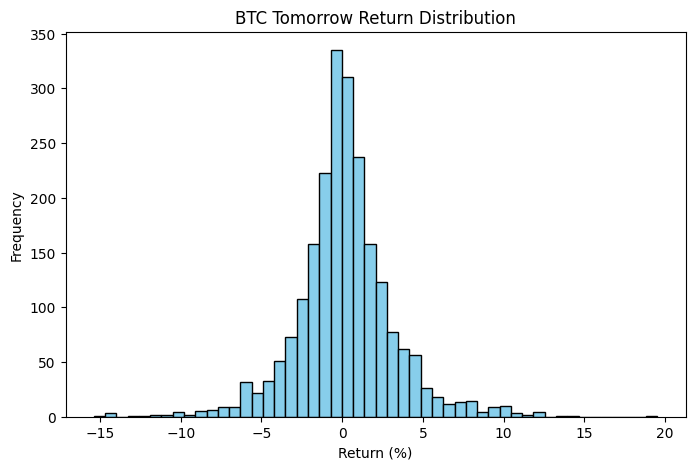

In [41]:
import matplotlib.pyplot as plt

# Example for BTC
plt.figure(figsize=(8,5))
plt.hist(df1['tomorrow_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('BTC Tomorrow Return Distribution')
plt.xlabel('Return (%)')
plt.ylabel('Frequency')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_10280\4186346857.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df1['tomorrow_return'], shade=True, color='orange')


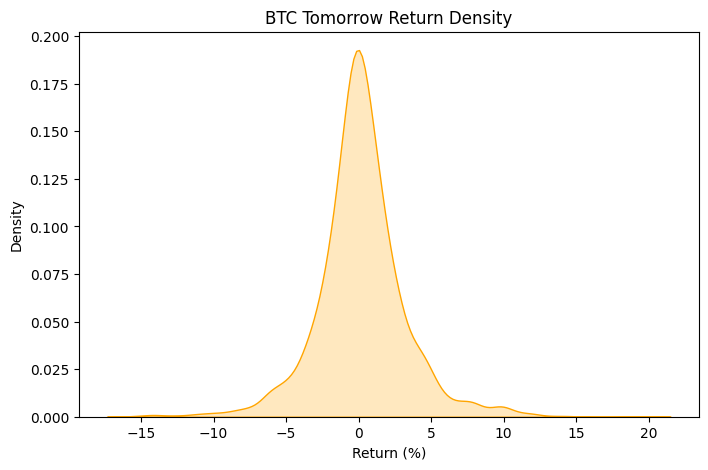

In [42]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(df1['tomorrow_return'], shade=True, color='orange')
plt.title('BTC Tomorrow Return Density')
plt.xlabel('Return (%)')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_10280\2788286287.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df1['tomorrow_return'], shade=True, color='lightblue')


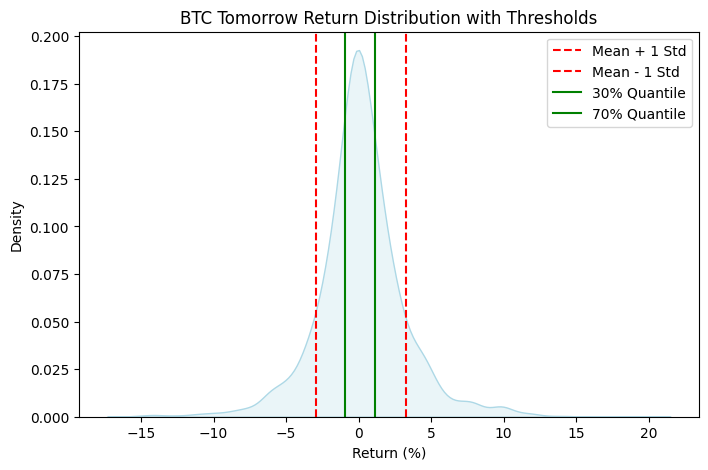

In [43]:
mean = df1['tomorrow_return'].mean()
std = df1['tomorrow_return'].std()
q_low = df1['tomorrow_return'].quantile(0.3)
q_high = df1['tomorrow_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(df1['tomorrow_return'], shade=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('BTC Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_10280\542878942.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df2['tomorrow_return'], shade=True, color='lightblue')


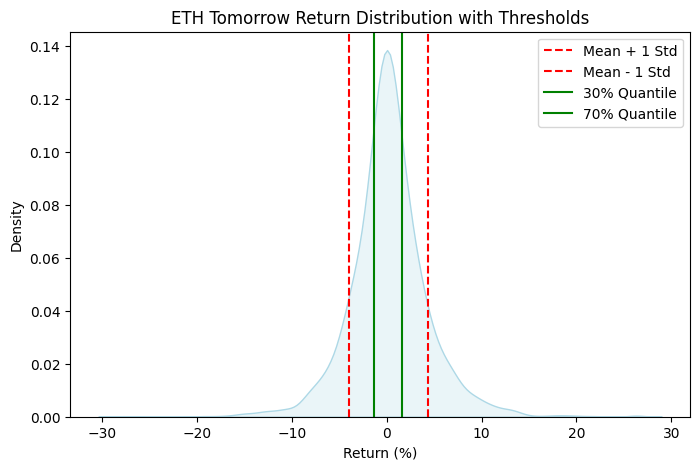

In [44]:
mean = df2['tomorrow_return'].mean()
std = df2['tomorrow_return'].std()
q_low = df2['tomorrow_return'].quantile(0.3)
q_high = df2['tomorrow_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(df2['tomorrow_return'], shade=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('ETH Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

In [45]:
df1[30:35]

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
30,2020-04-21,6828.98,6940.00,6762.00,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,7125.14,4.147853
31,2020-04-22,6841.36,7156.38,6818.00,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,7482.39,5.013937
32,2020-04-23,7125.12,7738.00,7020.00,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,7505.00,0.302176
33,2020-04-24,7483.96,7615.96,7388.00,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,7538.67,0.448634
34,2020-04-25,7505.00,7705.00,7431.07,7538.67,43874.427726,3.312921e+08,BTC,33.67,273.93,7205.734286,6901.351333,0.448634,3.169357,0.661556,1.616816,7693.10,2.048505


In [46]:
df2.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-03-22,132.63,137.13,121.10,122.32,1.055700e+06,1.359279e+08,ETH,-10.31,16.03,NaN,NaN,NaN,NaN,NaN,NaN,135.92,11.118378
1,2020-03-23,122.31,137.50,119.50,135.92,1.436796e+06,1.848516e+08,ETH,13.61,18.00,NaN,NaN,11.118378,NaN,NaN,NaN,138.42,1.839317
2,2020-03-24,135.89,143.36,132.20,138.42,1.244377e+06,1.711564e+08,ETH,2.53,11.16,NaN,NaN,1.839317,NaN,NaN,NaN,136.10,-1.676058
3,2020-03-25,138.42,142.33,132.54,136.10,1.034249e+06,1.417953e+08,ETH,-2.32,9.79,NaN,NaN,-1.676058,NaN,NaN,NaN,138.40,1.689934
4,2020-03-26,136.11,139.74,133.26,138.40,7.510606e+05,1.019188e+08,ETH,2.29,6.48,NaN,NaN,1.689934,NaN,NaN,NaN,131.33,-5.108382


In [47]:
df1.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
type                0
candle_body         0
high_low_range      0
MA_7                6
MA_30              29
moving_1d           1
volatility_7        7
volumelast7         6
z_score            29
tomorrow_close      0
tomorrow_return     0
dtype: int64

In [48]:
df1.dropna(inplace=True)
df2.dropna(inplace=True)

In [49]:
df1.reset_index(drop=True,inplace=True)
df2.reset_index(drop=True,inplace=True)

In [50]:
df1.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-04-20,7121.40,7220.00,6751.0,6826.83,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665,6841.37,0.212983
1,2020-04-21,6828.98,6940.00,6762.0,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,7125.14,4.147853
2,2020-04-22,6841.36,7156.38,6818.0,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,7482.39,5.013937
3,2020-04-23,7125.12,7738.00,7020.0,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,7505.00,0.302176
4,2020-04-24,7483.96,7615.96,7388.0,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,7538.67,0.448634


In [51]:
print(df2.shape) ## both of them was 2190 originally
print(df1.shape)

(2192, 18)
(2192, 18)


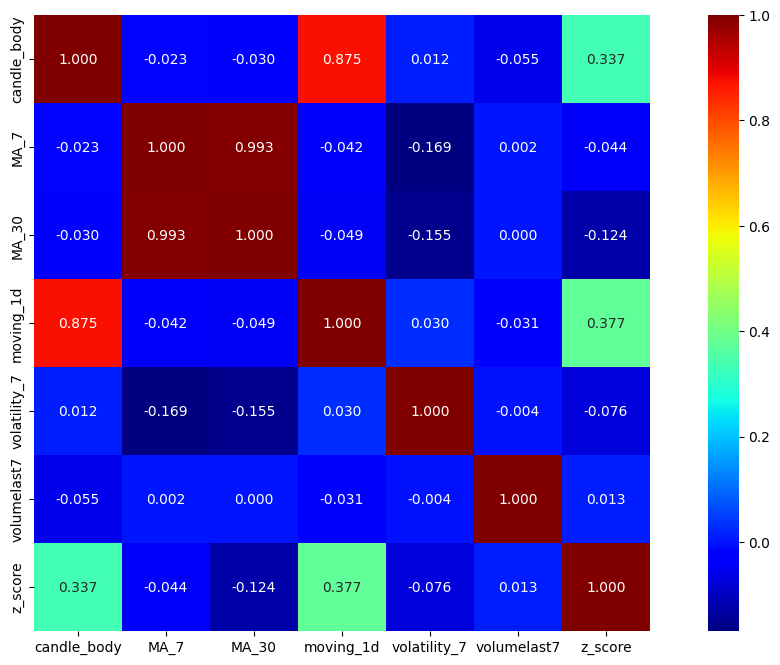

In [52]:
plt.figure(figsize=(15,8))
corr8=df1[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr8,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

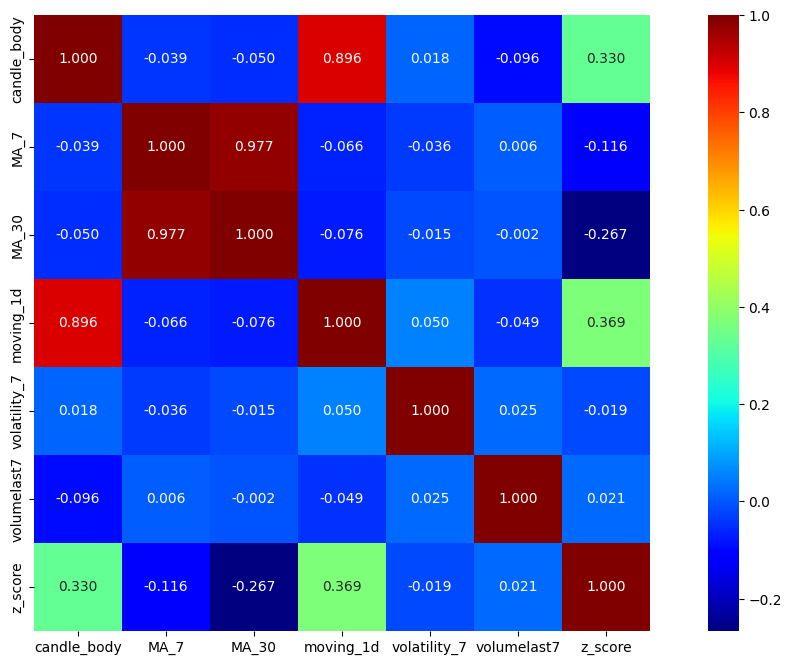

In [53]:
plt.figure(figsize=(15,8))
corr9=df2[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr9,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

In [54]:
combined=pd.concat([df1,df2],ignore_index=True)
combined.to_csv("eth_btc_data.csv",index=False)

In [55]:
df3=pd.read_csv("eth_btc_data.csv")

In [56]:
df3.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-04-20,7121.40,7220.00,6751.0,6826.83,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665,6841.37,0.212983
1,2020-04-21,6828.98,6940.00,6762.0,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,7125.14,4.147853
2,2020-04-22,6841.36,7156.38,6818.0,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,7482.39,5.013937
3,2020-04-23,7125.12,7738.00,7020.0,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,7505.00,0.302176
4,2020-04-24,7483.96,7615.96,7388.0,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,7538.67,0.448634


# **BNB_SOL**

In [57]:
df4 = pd.read_csv('all_data/bnb_6years_binance.csv')
df4.head(3)

,date,open,high,low,close,volume,quote_volume
0,2020-03-25,12.4261,12.7108,12.0561,12.3251,3607793.89,4.449144e+07
1,2020-03-26,12.3253,13.2565,12.1900,13.1990,3439169.72,4.290229e+07
2,2020-03-27,13.1989,13.3655,12.1600,12.3354,2778050.91,3.608494e+07


In [58]:
df5 = pd.read_csv('all_data/sol_6years_binance.csv')
df5.head(3)

,date,open,high,low,close,volume,quote_volume
0,2020-08-11,2.8500,3.5208,2.8433,3.2985,1552384.78,4.939149e+06
1,2020-08-12,3.2985,3.9289,3.0800,3.7558,1737042.95,6.176154e+06
2,2020-08-13,3.7500,4.1387,3.5003,3.7300,1685759.24,6.446568e+06


In [59]:
df4['type'] = 'BNB'
df5['type'] = 'SOL'

In [60]:
df4.head(1)

,date,open,high,low,close,volume,quote_volume,type
0,2020-03-25,12.4261,12.7108,12.0561,12.3251,3607793.89,4.449144e+07,BNB


In [61]:
df5.head(1)

,date,open,high,low,close,volume,quote_volume,type
0,2020-08-11,2.85,3.5208,2.8433,3.2985,1552384.78,4.939149e+06,SOL


In [62]:
df4.isna().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
quote_volume    0
type            0
dtype: int64

In [63]:
df5.isna().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
quote_volume    0
type            0
dtype: int64

In [64]:

df4.duplicated(subset='date').sum()

np.int64(0)

In [65]:
df5.duplicated(subset='date').sum()

np.int64(0)

In [66]:
df4['date']=pd.to_datetime(df4['date'])
df4['year']=df4['date'].dt.year
df4['year'].value_counts()

year
2024    366
2022    365
2021    365
2025    365
2023    365
2020    282
2026    111
Name: count, dtype: int64

In [67]:
df5['date']=pd.to_datetime(df5['date'])
df5['year']=df5['date'].dt.year
df5['year'].value_counts()

year
2024    366
2022    365
2021    365
2025    365
2023    365
2020    143
2026    111
Name: count, dtype: int64

In [68]:
df4.drop(columns='year',inplace=True)
df5.drop(columns='year',inplace=True)

In [69]:
df4.duplicated(subset='date').sum()

np.int64(0)

In [70]:
df5.duplicated(subset='date').sum()

np.int64(0)

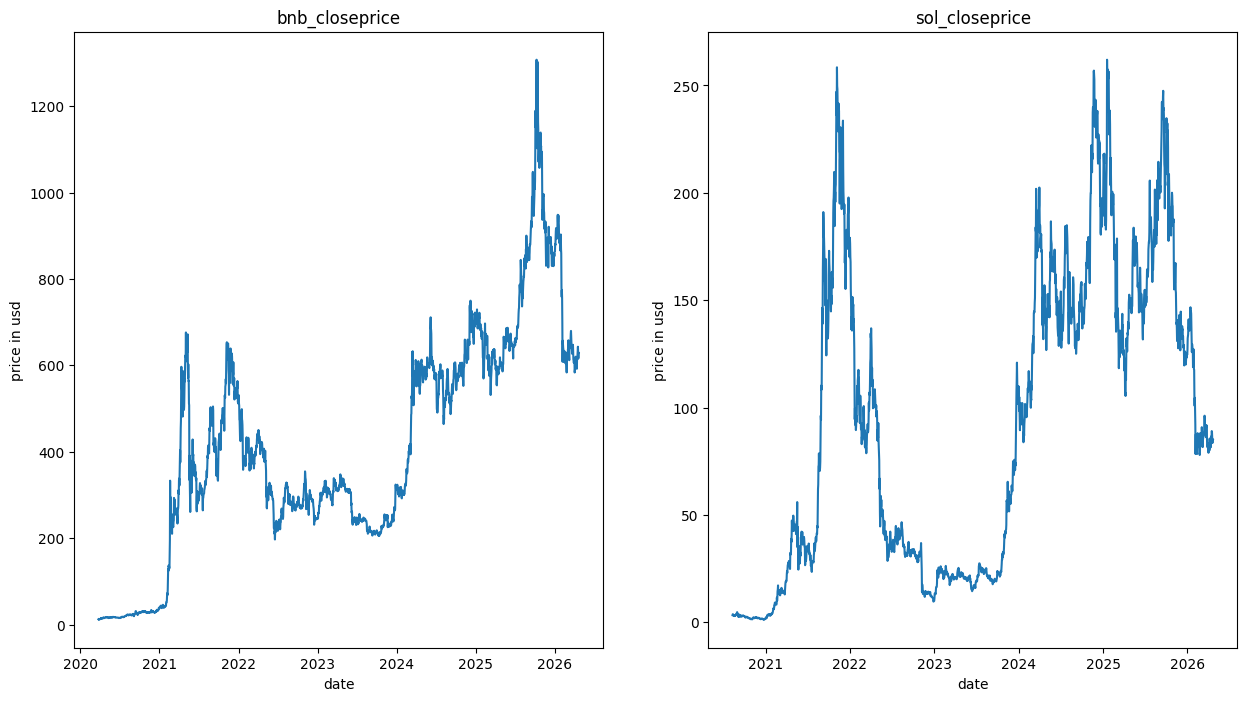

In [71]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df4,y='close')
plt.title("bnb_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df5,y='close')
plt.title("sol_closeprice")
plt.ylabel("price in usd")
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_10280\2521454798.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year',data=df4,y='close', palette = 'viridis')
C:\Users\ibrah\AppData\Local\Temp\ipykernel_10280\2521454798.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year',data=df5,y='close', palette = 'magma')


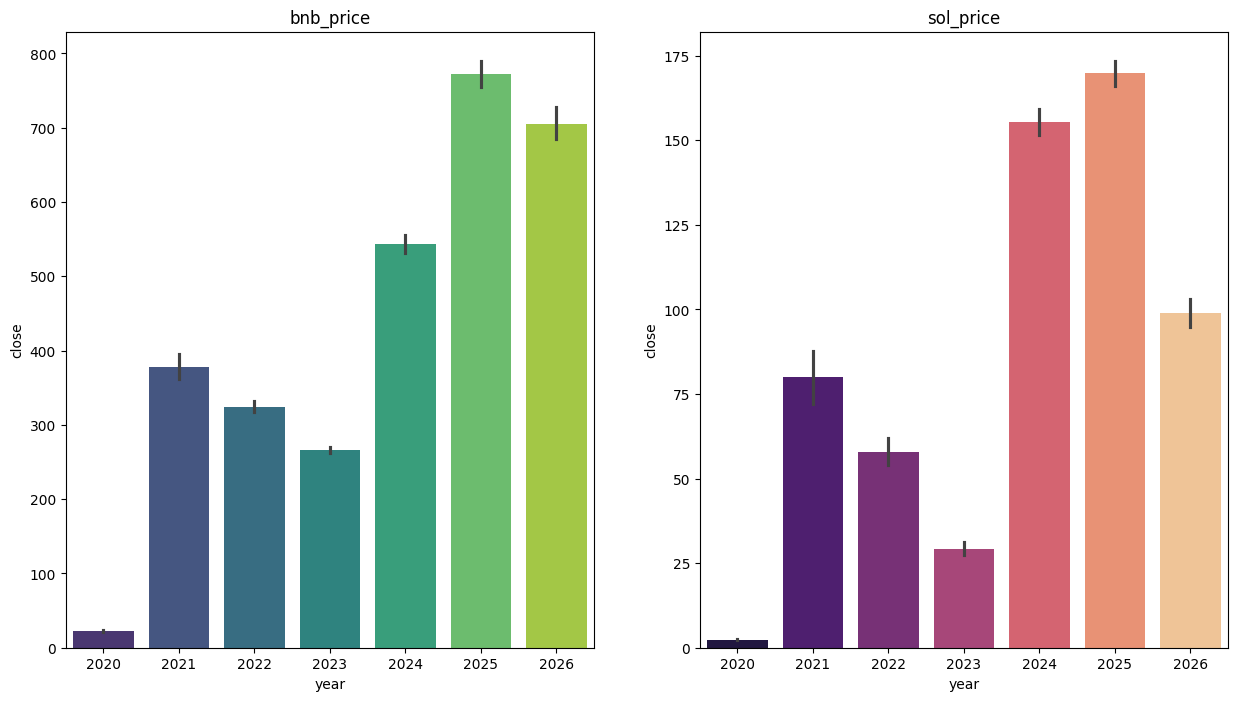

In [72]:
plt.figure(figsize=(15,8))
plt.subplot(1,2,1)
df4['year']=df4['date'].dt.year
sns.barplot(x='year',data=df4,y='close', palette = 'viridis')
plt.title("bnb_price")
plt.subplot(1,2,2)
df5['year']=df5['date'].dt.year
sns.barplot(x='year',data=df5,y='close', palette = 'magma')
plt.title("sol_price")
plt.show()

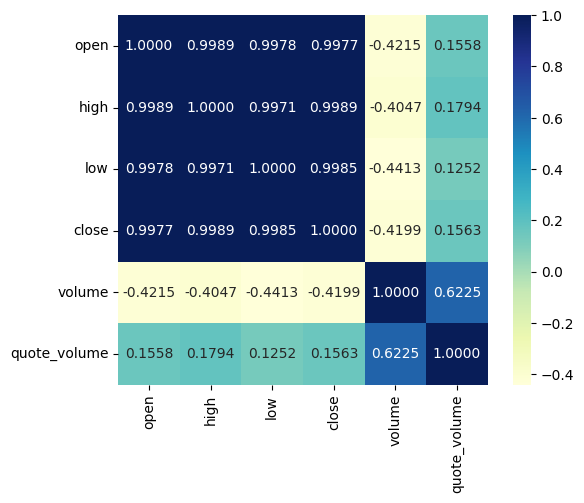

In [73]:
corr4=df4[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr4,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

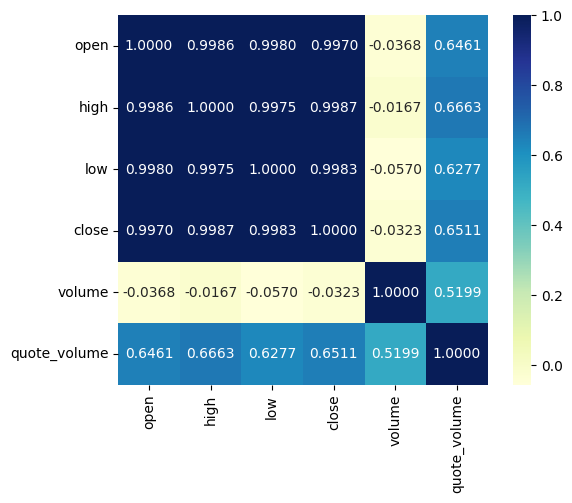

In [74]:
corr5=df5[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr5,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [75]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    bnb_year = df4[df4['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x = bnb_year['date'],
        open = bnb_year['open'],
        high = bnb_year['high'],
        low = bnb_year['low'],
        close = bnb_year['close']
    )])

    fig.update_layout(title=f'BNB Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    bnb_year = df4[df4['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x = bnb_year['date'],\n        open = bnb_year['open'],\n        high = bnb_year['high'],\n        low = bnb_year['low'],\n        close = bnb_year['close']\n    )])\n\n    fig.update_layout(title=f'BNB Candlestick Chart - {year}')\n    fig.show()"

In [76]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    sol_year = df5[df5['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x = sol_year['date'],
        open = sol_year['open'],
        high = sol_year['high'],
        low = sol_year['low'],
        close = sol_year['close']
    )])

    fig.update_layout(title=f'SOL Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    sol_year = df5[df5['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x = sol_year['date'],\n        open = sol_year['open'],\n        high = sol_year['high'],\n        low = sol_year['low'],\n        close = sol_year['close']\n    )])\n\n    fig.update_layout(title=f'SOL Candlestick Chart - {year}')\n    fig.show()"

In [77]:
df4['candle_body']=df4['close']-df4['open']
df5['candle_body']=df5['close']-df5['open']

df4['high_low_range']=df4['high']-df4['low']
df5['high_low_range']=df5['high']-df5['low']

In [78]:
df4['MA_7']=df4['close'].rolling(window=7).mean()
df5['MA_7']=df5['close'].rolling(window=7).mean()

df4['MA_30']=df4['close'].rolling(window=30).mean()
df5['MA_30']=df5['close'].rolling(window=30).mean()

In [79]:
df4['moving_1d']=(df4['close']-df4['close'].shift(1))/df4['close'].shift(1) * 100
df5['moving_1d']=(df5['close']-df5['close'].shift(1))/df5['close'].shift(1) * 100

In [80]:
df4["volatility_7"] = df4["moving_1d"].rolling(window=7).std()
df5["volatility_7"] = df5["moving_1d"].rolling(window=7).std()

In [81]:
df4["volume_MA7"] = df4["volume"].rolling(window=7).mean()
df4["volumelast7"] = df4["volume"] / df4["volume_MA7"]
df5["volume_MA7"] = df5["volume"].rolling(window=7).mean()
df5["volumelast7"] = df5["volume"] / df5["volume_MA7"]

In [82]:
df4["rolling_mean_30"] = df4["close"].rolling(window=30).mean()
df4["rolling_std_30"]  = df4["close"].rolling(window=30).std()
df4["z_score"] = (df4["close"] - df4["rolling_mean_30"]) / df4["rolling_std_30"]

In [83]:
df5["rolling_mean_30"] = df5["close"].rolling(window=30).mean()
df5["rolling_std_30"]  = df5["close"].rolling(window=30).std()
df5["z_score"] = (df5["close"] - df5["rolling_mean_30"]) / df5["rolling_std_30"]

In [84]:
df4.drop(columns='volume_MA7',inplace=True)
df4.drop(columns='rolling_mean_30',inplace=True)
df4.drop(columns='rolling_std_30',inplace=True)
df5.drop(columns='volume_MA7',inplace=True)
df5.drop(columns='rolling_mean_30',inplace=True)
df5.drop(columns='rolling_std_30',inplace=True)

In [85]:
df4['tomorrow_close'] = df4['close'].shift(-1)
df4['tomorrow_return'] = (df4['tomorrow_close'] - df4['close']) / df4['close'] * 100

df4.head(3)

,date,open,high,low,close,volume,quote_volume,type,year,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-03-25,12.4261,12.7108,12.0561,12.3251,3607793.89,4.449144e+07,BNB,2020,-0.1010,0.6547,NaN,NaN,NaN,NaN,NaN,NaN,13.1990,7.090409
1,2020-03-26,12.3253,13.2565,12.1900,13.1990,3439169.72,4.290229e+07,BNB,2020,0.8737,1.0665,NaN,NaN,7.090409,NaN,NaN,NaN,12.3354,-6.542920
2,2020-03-27,13.1989,13.3655,12.1600,12.3354,2778050.91,3.608494e+07,BNB,2020,-0.8635,1.2055,NaN,NaN,-6.542920,NaN,NaN,NaN,12.1888,-1.188450


In [86]:
df5['tomorrow_close'] = df5['close'].shift(-1)
df5['tomorrow_return'] = (df5['tomorrow_close'] - df5['close']) / df5['close'] * 100

df5.head(3)

,date,open,high,low,close,volume,quote_volume,type,year,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-08-11,2.8500,3.5208,2.8433,3.2985,1552384.78,4.939149e+06,SOL,2020,0.4485,0.6775,NaN,NaN,NaN,NaN,NaN,NaN,3.7558,13.863878
1,2020-08-12,3.2985,3.9289,3.0800,3.7558,1737042.95,6.176154e+06,SOL,2020,0.4573,0.8489,NaN,NaN,13.863878,NaN,NaN,NaN,3.7300,-0.686938
2,2020-08-13,3.7500,4.1387,3.5003,3.7300,1685759.24,6.446568e+06,SOL,2020,-0.0200,0.6384,NaN,NaN,-0.686938,NaN,NaN,NaN,3.4099,-8.581769


In [87]:
df4.drop("year",axis=1,inplace=True)
df5.drop("year",axis=1,inplace=True)


In [88]:
print(df4.isna().sum())
print("-"*50)
print(df5.isna().sum())

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
type                0
candle_body         0
high_low_range      0
MA_7                6
MA_30              29
moving_1d           1
volatility_7        7
volumelast7         6
z_score            29
tomorrow_close      1
tomorrow_return     1
dtype: int64
--------------------------------------------------
date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
type                0
candle_body         0
high_low_range      0
MA_7                6
MA_30              29
moving_1d           1
volatility_7        7
volumelast7         6
z_score            29
tomorrow_close      1
tomorrow_return     1
dtype: int64


In [89]:
df4.dropna(inplace=True)
df5.dropna(inplace=True)
df4.reset_index(drop=True,inplace=True)
df5.reset_index(drop=True,inplace=True)

In [90]:
df4.shape

(2189, 18)

## XRP and AVAX(cordano)

In [91]:
df6=pd.read_csv("all_data/xrp_6years_binance.csv")
df7=pd.read_csv("all_data/avax_6years_binance.csv")

In [92]:
df7.shape

(2038, 7)

In [93]:
df6.head()

,date,open,high,low,close,volume,quote_volume
0,2020-03-28,0.17271,0.17984,0.16637,0.17543,308477933.9,5.293132e+07
1,2020-03-29,0.17540,0.17670,0.16184,0.16278,187119450.1,3.177006e+07
2,2020-03-30,0.16279,0.17546,0.16242,0.17112,181804091.3,3.113911e+07
3,2020-03-31,0.17109,0.17789,0.17044,0.17353,158613778.6,2.763097e+07
4,2020-04-01,0.17359,0.17630,0.16783,0.17494,184017110.9,3.170506e+07


In [94]:
df7.head()

,date,open,high,low,close,volume,quote_volume
0,2020-09-22,0.8500,7.0000,0.8500,5.3193,31441883.16,1.667153e+08
1,2020-09-23,5.3279,5.3600,3.4000,3.5350,12620608.01,5.315522e+07
2,2020-09-24,3.5305,4.8873,3.4033,4.6411,7107843.86,2.891253e+07
3,2020-09-25,4.6366,5.0234,4.2001,4.7134,3886096.71,1.791068e+07
4,2020-09-26,4.7164,4.8200,4.3294,4.5200,1814932.97,8.304264e+06


In [95]:
df6.isna().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
quote_volume    0
dtype: int64

In [96]:
df7.isna().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
quote_volume    0
dtype: int64

In [97]:
df6["date"]=pd.to_datetime(df6['date'])
df6["year"]=df6['date'].dt.year
df6['year'].value_counts()

year
2024    366
2022    365
2021    365
2025    365
2023    365
2020    279
2026    111
Name: count, dtype: int64

In [98]:
df6=df6.drop(columns="year")
df6.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume'], dtype='object')

In [99]:
df7["type"]='ADA'
df7.head(10)

,date,open,high,low,close,volume,quote_volume,type
0,2020-09-22,0.8500,7.0000,0.8500,5.3193,31441883.16,1.667153e+08,ADA
1,2020-09-23,5.3279,5.3600,3.4000,3.5350,12620608.01,5.315522e+07,ADA
2,2020-09-24,3.5305,4.8873,3.4033,4.6411,7107843.86,2.891253e+07,ADA
3,2020-09-25,4.6366,5.0234,4.2001,4.7134,3886096.71,1.791068e+07,ADA
4,2020-09-26,4.7164,4.8200,4.3294,4.5200,1814932.97,8.304264e+06,ADA
5,2020-09-27,4.5214,4.7134,4.1068,4.6484,1500134.56,6.626177e+06,ADA
6,2020-09-28,4.6485,4.7050,4.1667,4.2021,1210446.38,5.281811e+06,ADA
7,2020-09-29,4.1999,4.2899,3.9607,4.1394,1057878.53,4.361853e+06,ADA
8,2020-09-30,4.1429,4.4110,3.9958,4.3293,915518.31,3.839122e+06,ADA
9,2020-10-01,4.3293,4.5300,4.0140,4.1500,1477288.72,6.232982e+06,ADA


In [100]:
df6["type"]='XRP'
df6.head(10)

,date,open,high,low,close,volume,quote_volume,type
0,2020-03-28,0.17271,0.17984,0.16637,0.17543,308477933.9,5.293132e+07,XRP
1,2020-03-29,0.17540,0.17670,0.16184,0.16278,187119450.1,3.177006e+07,XRP
2,2020-03-30,0.16279,0.17546,0.16242,0.17112,181804091.3,3.113911e+07,XRP
3,2020-03-31,0.17109,0.17789,0.17044,0.17353,158613778.6,2.763097e+07,XRP
4,2020-04-01,0.17359,0.17630,0.16783,0.17494,184017110.9,3.170506e+07,XRP
5,2020-04-02,0.17497,0.18650,0.17384,0.17828,223398206.0,3.983105e+07,XRP
6,2020-04-03,0.17828,0.18277,0.17568,0.17957,170663444.5,3.061190e+07,XRP
7,2020-04-04,0.17956,0.18365,0.17770,0.18114,117148787.3,2.107374e+07,XRP
8,2020-04-05,0.18114,0.18206,0.17627,0.17925,83641306.3,1.500608e+07,XRP
9,2020-04-06,0.17927,0.19834,0.17917,0.19803,225433233.4,4.264767e+07,XRP


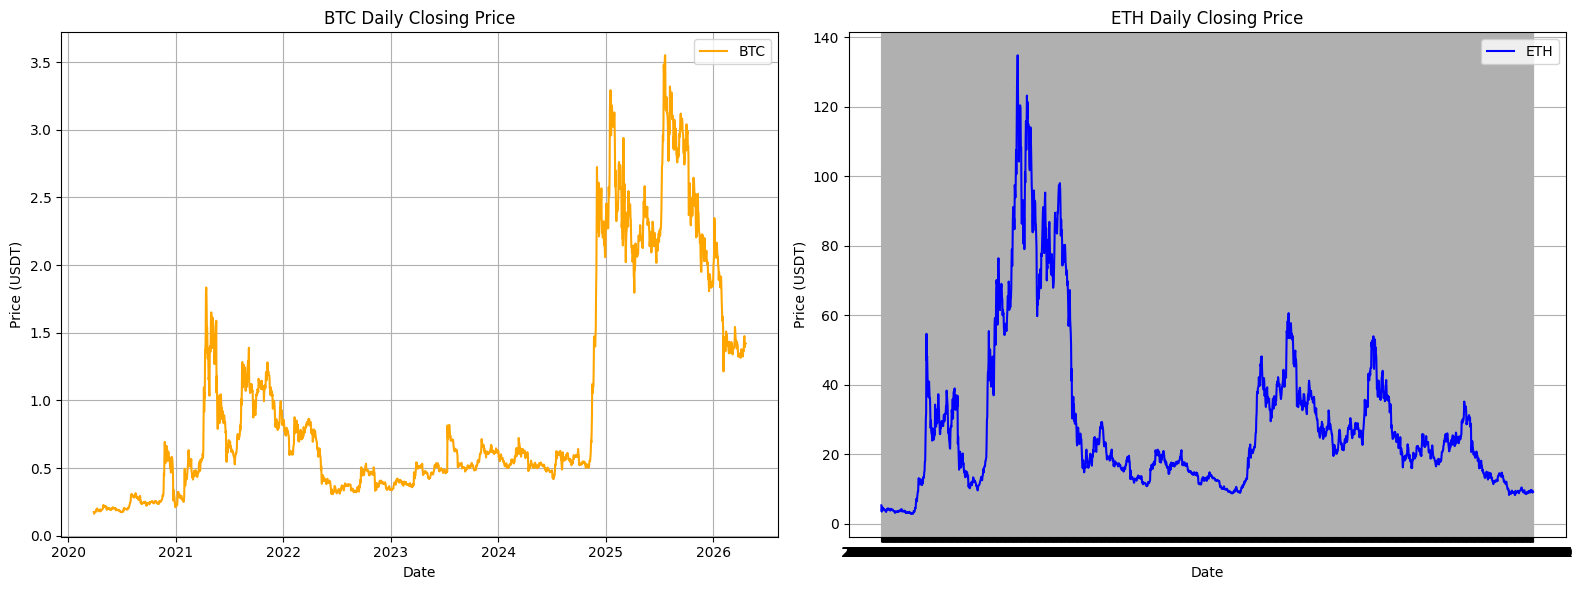

In [101]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.plot(df6['date'], df6['close'], label='BTC', color='orange')
plt.title("BTC Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USDT)")
plt.legend()
plt.grid(True)
plt.subplot(1,2,2)
sns.lineplot(x=df7['date'], y=df7['close'], label='ETH', color='blue')
plt.title("ETH Daily Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USDT)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

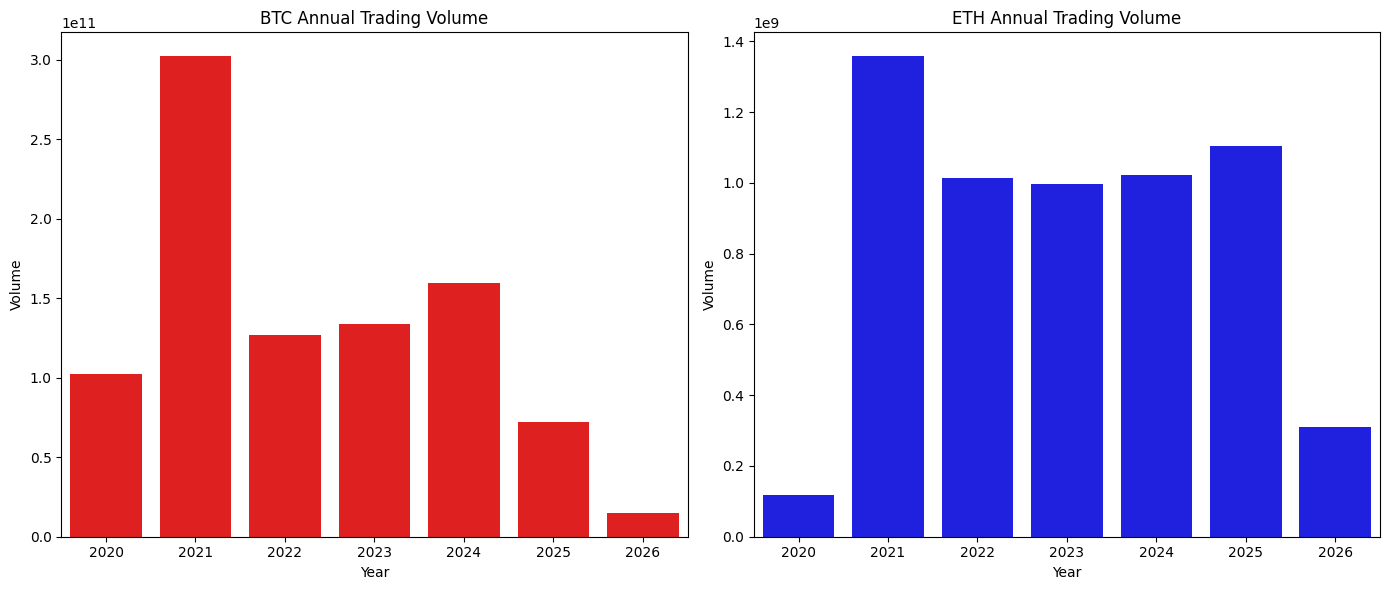

In [102]:

df6['date'] = pd.to_datetime(df6['date'], errors='coerce')
df7['date'] = pd.to_datetime(df7['date'], errors='coerce')
df6 = df6.dropna(subset=['date'])
df7 = df7.dropna(subset=['date'])
df6['year'] = df6['date'].dt.year
df7['year'] = df7['date'].dt.year
btc_yearly = df6.groupby('year')['volume'].sum().reset_index()
eth_yearly = df7.groupby('year')['volume'].sum().reset_index()
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
sns.barplot(x='year', y='volume', data=btc_yearly, color='red')
plt.title("BTC Annual Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume")
plt.subplot(1,2,2)
sns.barplot(x='year', y='volume', data=eth_yearly, color='blue')
plt.title("ETH Annual Trading Volume")
plt.xlabel("Year")
plt.ylabel("Volume")

plt.tight_layout()
plt.show()

In [103]:
df6[['open','high','low','close','volume','quote_volume']].describe()

,open,high,low,close,volume,quote_volume
count,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2.216000e+03
mean,0.955695,0.989093,0.919813,0.956258,4.117357e+08,3.492206e+08
std,0.803703,0.830325,0.775701,0.803590,4.848705e+08,4.916309e+08
min,0.162790,0.175460,0.161840,0.162780,2.659724e+07,1.115895e+07
25%,0.427025,0.448137,0.407350,0.427735,1.611925e+08,1.116194e+08
50%,0.586800,0.609200,0.565890,0.586800,2.896736e+08,2.023065e+08
75%,1.271450,1.337525,1.200000,1.279700,4.564383e+08,3.821150e+08
max,3.550400,3.660700,3.421800,3.550400,8.608358e+09,6.398461e+09


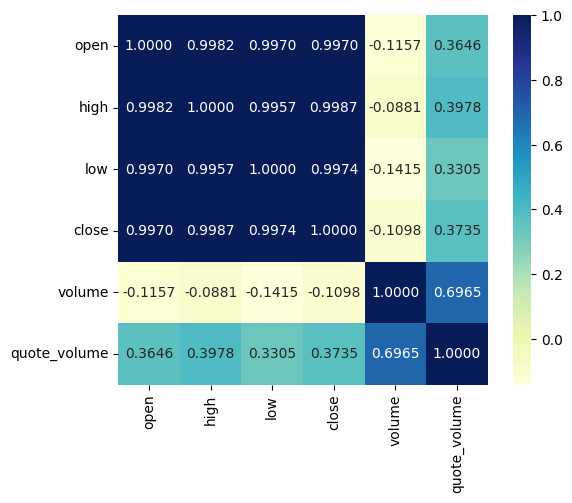

In [104]:

corr1 = df6[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1, annot=True, square=True, fmt='.4f', cmap='YlGnBu')
plt.show()

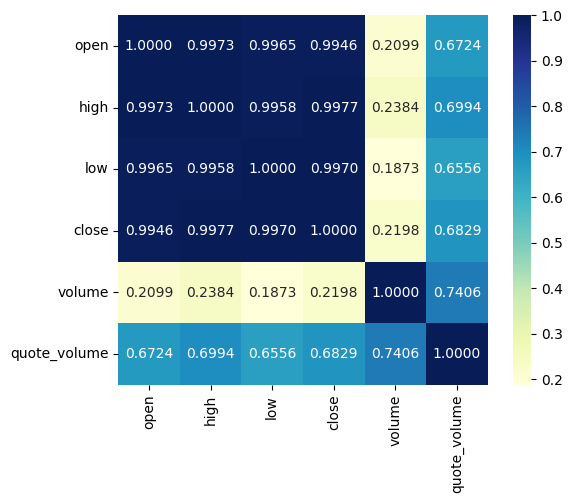

In [105]:

corr2=df7[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [106]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:
    btc_year = df6[df6['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])

    fig.update_layout(title=f'BTC Candlestick Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:\n    btc_year = df6[df6['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_year['date'],\n        open=btc_year['open'],\n        high=btc_year['high'],\n        low=btc_year['low'],\n        close=btc_year['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick Chart - {year}')\n    fig.show()"

In [107]:

"""years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
    2025: [1, 3, 12],
    2026: [2, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df6[(df6['date'].dt.year == year) & (df6['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])

    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"years_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n    2025: [1, 3, 12],\n    2026: [2, 3, 11],\n}\nfor year, months in years_months.items():\n    btc_filtered = df6[(df6['date'].dt.year == year) & (df6['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_filtered['date'],\n        open=btc_filtered['open'],\n        high=btc_filtered['high'],\n        low=btc_filtered['low'],\n        close=btc_filtered['close']\n    )])\n\n    fig.update_layout(title=f'BTC Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [108]:
df7['date'] = pd.to_datetime(df7['date'], errors='coerce')
df6['date'] = pd.to_datetime(df6['date'], errors='coerce')

In [109]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:
    btc_year = df7[df7['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_year['date'],
        open=btc_year['open'],
        high=btc_year['high'],
        low=btc_year['low'],
        close=btc_year['close']
    )])

    fig.update_layout(title=f'ETH Candlestick Chart - {year}')
    fig.show()"""


"for year in [2020, 2021, 2022, 2023, 2024,2025,2026]:\n    btc_year = df7[df7['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_year['date'],\n        open=btc_year['open'],\n        high=btc_year['high'],\n        low=btc_year['low'],\n        close=btc_year['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick Chart - {year}')\n    fig.show()"

In [110]:
"""years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
    2025: [1, 3, 12],
    2026: [2, 3, 11],
}
for year, months in years_months.items():
    btc_filtered = df7[(df7['date'].dt.year == year) & (df7['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=btc_filtered['date'],
        open=btc_filtered['open'],
        high=btc_filtered['high'],
        low=btc_filtered['low'],
        close=btc_filtered['close']
    )])

    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"years_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n    2025: [1, 3, 12],\n    2026: [2, 3, 11],\n}\nfor year, months in years_months.items():\n    btc_filtered = df7[(df7['date'].dt.year == year) & (df7['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=btc_filtered['date'],\n        open=btc_filtered['open'],\n        high=btc_filtered['high'],\n        low=btc_filtered['low'],\n        close=btc_filtered['close']\n    )])\n\n    fig.update_layout(title=f'ETH Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [111]:

df6['high_low_range'] = df6['high'] - df6['low']
df7['high_low_range'] = df7['high'] - df7['low']
df6["candle_body"]=df6['close']-df6['open']
df7['candle_body']=df2['close']-df7['open']
df6['MA_7'] = df6['close'].rolling(window=7).mean()
df7['MA_7'] = df7['close'].rolling(window=7).mean()
df6['MA_30'] = df6['close'].rolling(window=30).mean()
df7['MA_30'] = df7['close'].rolling(window=30).mean()
df6['moving_1d'] = (df6['close'] - df6['close'].shift(1)) / df6['close'].shift(1) * 100
df7['moving_1d'] = (df7['close'] - df7['close'].shift(1)) / df7['close'].shift(1) * 100
df6['volatility_7'] = df6['moving_1d'].rolling(window=7).std()
df7['volatility_7'] = df7['moving_1d'].rolling(window=7).std()
df6['volume_MA7'] = df6['volume'].rolling(window=7).mean()
df6['volumelast7'] = df6['volume'] / df6['volume_MA7']
df7['volume_MA7'] = df7['volume'].rolling(window=7).mean()
df7['volumelast7'] = df7['volume'] / df7['volume_MA7']
df6.drop(columns='volume_MA7', inplace=True)
df7.drop(columns='volume_MA7', inplace=True)
df6['rolling_mean_30'] = df6['close'].rolling(window=30).mean()
df6['rolling_std_30']  = df6['close'].rolling(window=30).std()
df6['z_score'] = (df6['close'] - df6['rolling_mean_30']) / df6['rolling_std_30']
df7['rolling_mean_30'] = df7['close'].rolling(window=30).mean()
df7['rolling_std_30']  = df7['close'].rolling(window=30).std()
df7['z_score'] = (df7['close'] - df7['rolling_mean_30']) / df7['rolling_std_30']
df6.drop(columns=['rolling_mean_30', 'rolling_std_30'], inplace=True)
df7.drop(columns=['rolling_mean_30', 'rolling_std_30'], inplace=True)
df6['tomorrow_close'] = df6['close'].shift(-1)
df6['tomorrow_return'] = (df6['tomorrow_close'] - df6['close']) / df6['close'] * 100
df7['tomorrow_close'] = df7['close'].shift(-1)
df7['tomorrow_return'] = (df7['tomorrow_close'] - df7['close']) / df7['close'] * 100
print("Feature Engineering for df6 (BTC) and df7 (ETH) completed!")

Feature Engineering for df6 (BTC) and df7 (ETH) completed!


In [112]:
from scipy.stats import skew, kurtosis
def compute_stats(df, name):
    df_clean = df.dropna(subset=['tomorrow_return'])
    skew_val = skew(df_clean['tomorrow_return'])
    kurt_val = kurtosis(df_clean['tomorrow_return'])
    print(f"{name} Tomorrow Return Stats:")
    print(f"  Skewness: {skew_val:.4f}")
    print(f"  Kurtosis: {kurt_val:.4f}")
    return skew_val, kurt_val
skew6, kurt6 = compute_stats(df6, "BTC")
skew7, kurt7 = compute_stats(df7, "ETH")

BTC Tomorrow Return Stats:
  Skewness: 2.5034
  Kurtosis: 29.1526
ETH Tomorrow Return Stats:
  Skewness: 1.1853
  Kurtosis: 12.8248


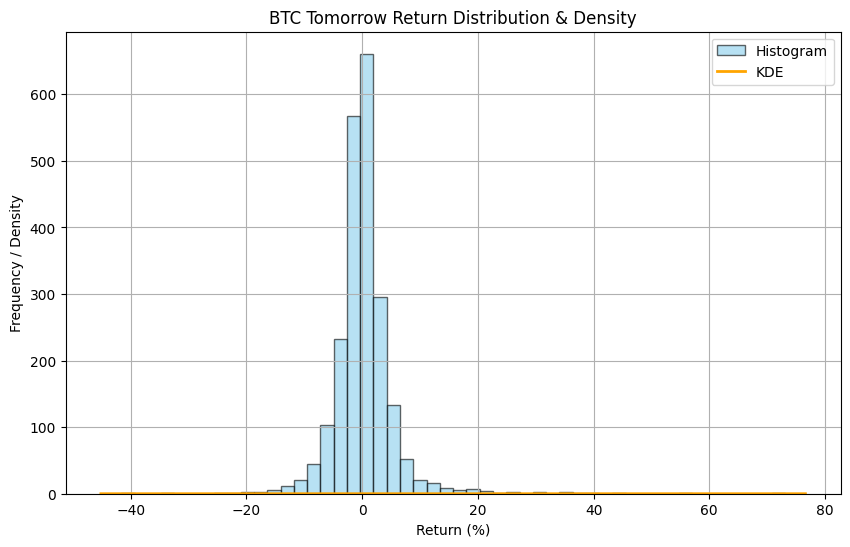

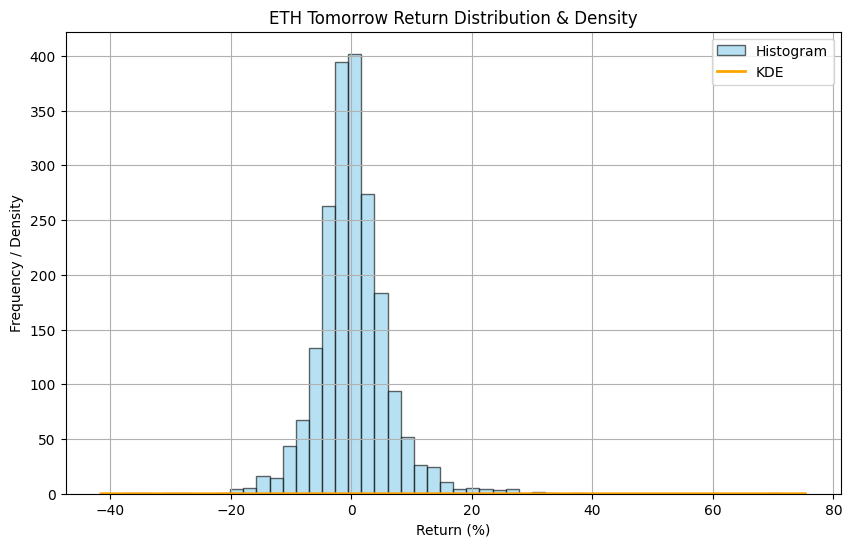

In [113]:

def plot_return_distribution(df, name):
    plt.figure(figsize=(10,6))
    plt.hist(df['tomorrow_return'].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.6, label='Histogram')
    sns.kdeplot(df['tomorrow_return'].dropna(), color='orange', lw=2, label='KDE')
    plt.title(f'{name} Tomorrow Return Distribution & Density')
    plt.xlabel('Return (%)')
    plt.ylabel('Frequency / Density')
    plt.legend()
    plt.grid(True)
    plt.show()
plot_return_distribution(df6, 'BTC')
plot_return_distribution(df7, 'ETH')

In [114]:
df6.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
type                0
year                0
high_low_range      0
candle_body         0
MA_7                6
MA_30              29
moving_1d           1
volatility_7        7
volumelast7         6
z_score            29
tomorrow_close      1
tomorrow_return     1
dtype: int64

In [115]:

df6.dropna(inplace=True)
df7.dropna(inplace=True)
df6.reset_index(drop=True,inplace=True)
df7.reset_index(drop=True,inplace=True)
df6.head(10)

,date,open,high,low,close,volume,quote_volume,type,year,high_low_range,candle_body,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-04-26,0.19414,0.19775,0.19133,0.19618,93225699.4,1.819580e+07,XRP,2020,0.00642,0.00204,0.189881,0.185988,1.029972,2.173845,0.772587,1.122018,0.19747,0.657559
1,2020-04-27,0.19620,0.19979,0.19407,0.19747,104536714.3,2.055780e+07,XRP,2020,0.00572,0.00127,0.192161,0.186723,0.657559,0.900034,0.943987,1.182124,0.21416,8.451917
2,2020-04-28,0.19750,0.21806,0.19459,0.21416,244843302.1,5.069336e+07,XRP,2020,0.02347,0.01666,0.196554,0.188435,8.451917,2.868702,1.887046,2.776976,0.22648,5.752708
3,2020-04-29,0.21415,0.23075,0.20981,0.22648,292096742.3,6.455231e+07,XRP,2020,0.02094,0.01233,0.202046,0.190281,5.752708,3.160595,1.848001,3.279184,0.21135,-6.680502
4,2020-04-30,0.22644,0.23590,0.20816,0.21135,314088335.1,6.947316e+07,XRP,2020,0.02774,-0.01509,0.204724,0.191541,-6.680502,4.771857,1.771078,1.765745,0.21786,3.080199
5,2020-05-01,0.21135,0.22418,0.21117,0.21786,160339801.0,3.492037e+07,XRP,2020,0.01301,0.00651,0.208240,0.192972,3.080199,4.779517,0.871473,2.117728,0.22369,2.676030
6,2020-05-02,0.21785,0.22575,0.21534,0.22369,119932182.7,2.651578e+07,XRP,2020,0.01041,0.00584,0.212456,0.194486,2.676030,4.748584,0.631667,2.302776,0.21936,-1.935715
7,2020-05-03,0.22377,0.22667,0.21540,0.21936,111226961.6,2.462415e+07,XRP,2020,0.01127,-0.00441,0.215767,0.195812,-1.935715,4.990104,0.577989,1.791963,0.21776,-0.729395
8,2020-05-04,0.21936,0.22057,0.20713,0.21776,166756745.3,3.576719e+07,XRP,2020,0.01344,-0.00160,0.218666,0.197033,-0.729395,5.066027,0.828291,1.543512,0.21688,-0.404115
9,2020-05-05,0.21777,0.22213,0.21316,0.21688,106925948.7,2.326301e+07,XRP,2020,0.00897,-0.00089,0.219054,0.198287,-0.404115,4.049109,0.588722,1.380554,0.21158,-2.443748


In [116]:
df7.shape

(2008, 19)

In [117]:
df6.drop("year",axis=1,inplace=True)
df7.drop("year",axis=1,inplace=True)

AVAX_DOGE

In [118]:
doge_price=pd.read_csv('all_data/doge_6years_binance.csv')
avax_price=pd.read_csv('all_data/avax_6years_binance.csv')

In [119]:
doge_price.head()

,date,open,high,low,close,volume,quote_volume
0,2020-04-04,0.001847,0.001909,0.001828,0.001870,92364705.0,171975.042374
1,2020-04-05,0.001875,0.001882,0.001838,0.001850,55344996.0,102948.075591
2,2020-04-06,0.001847,0.001990,0.001844,0.001990,210552139.0,404969.943854
3,2020-04-07,0.001989,0.002021,0.001950,0.001994,202961221.0,404348.051512
4,2020-04-08,0.001997,0.002043,0.001967,0.002004,90384907.0,181433.658845


In [120]:
avax_price.head()

,date,open,high,low,close,volume,quote_volume
0,2020-09-22,0.8500,7.0000,0.8500,5.3193,31441883.16,1.667153e+08
1,2020-09-23,5.3279,5.3600,3.4000,3.5350,12620608.01,5.315522e+07
2,2020-09-24,3.5305,4.8873,3.4033,4.6411,7107843.86,2.891253e+07
3,2020-09-25,4.6366,5.0234,4.2001,4.7134,3886096.71,1.791068e+07
4,2020-09-26,4.7164,4.8200,4.3294,4.5200,1814932.97,8.304264e+06


In [121]:
doge_price["date"] = pd.to_datetime(doge_price["date"])
doge_price["year"] = doge_price["date"].dt.year

In [122]:
doge_price['year'].value_counts()

year
2024    366
2022    365
2021    365
2025    365
2023    365
2020    272
2026    111
Name: count, dtype: int64

In [123]:
doge_price=doge_price.drop(columns="year")

In [124]:
doge_price.columns

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'quote_volume'], dtype='object')

In [125]:
doge_price.isna().sum()

date            0
open            0
high            0
low             0
close           0
volume          0
quote_volume    0
dtype: int64

In [126]:
doge_price.duplicated(subset='date').sum()

np.int64(0)

In [127]:
avax_price["date"] = pd.to_datetime(avax_price["date"])

In [128]:
avax_price.duplicated(subset='date').sum()

np.int64(0)

In [129]:
doge_price['type'] = 'DOGE'

In [130]:
doge_price.head()

,date,open,high,low,close,volume,quote_volume,type
0,2020-04-04,0.001847,0.001909,0.001828,0.001870,92364705.0,171975.042374,DOGE
1,2020-04-05,0.001875,0.001882,0.001838,0.001850,55344996.0,102948.075591,DOGE
2,2020-04-06,0.001847,0.001990,0.001844,0.001990,210552139.0,404969.943854,DOGE
3,2020-04-07,0.001989,0.002021,0.001950,0.001994,202961221.0,404348.051512,DOGE
4,2020-04-08,0.001997,0.002043,0.001967,0.002004,90384907.0,181433.658845,DOGE


In [131]:
avax_price['type'] = 'AVAX'

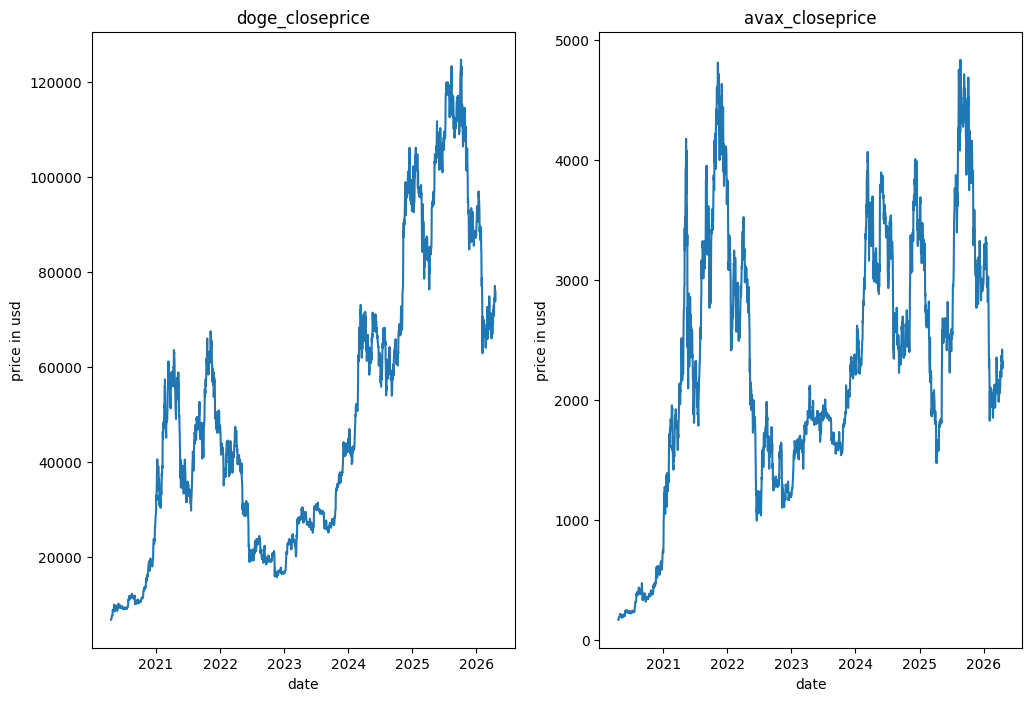

In [132]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
sns.lineplot(x='date',data=df1,y='close')
plt.title("doge_closeprice")
plt.ylabel("price in usd")
plt.subplot(1,2,2)
sns.lineplot(x='date',data=df2,y='close')
plt.title("avax_closeprice")
plt.ylabel("price in usd")
plt.show()

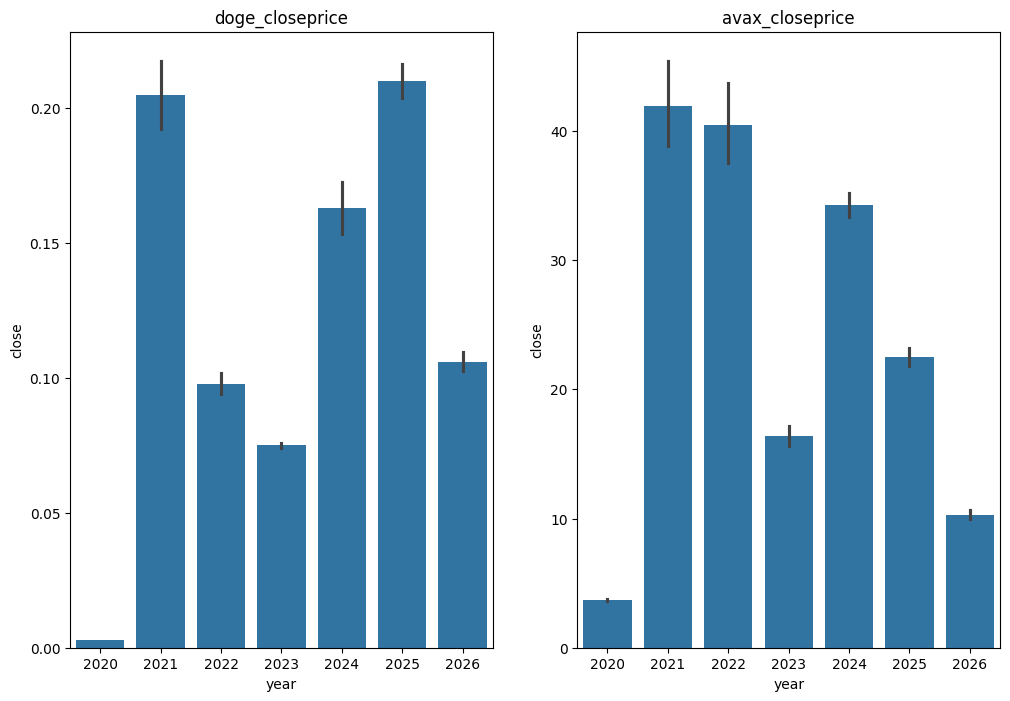

In [133]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
doge_price["year"]=doge_price["date"].dt.year
sns.barplot(x='year',data=doge_price,y='close')
plt.title("doge_closeprice")
plt.subplot(1,2,2)
avax_price["year"]=avax_price["date"].dt.year
sns.barplot(x='year',data=avax_price,y='close')
plt.title("avax_closeprice")
plt.show()

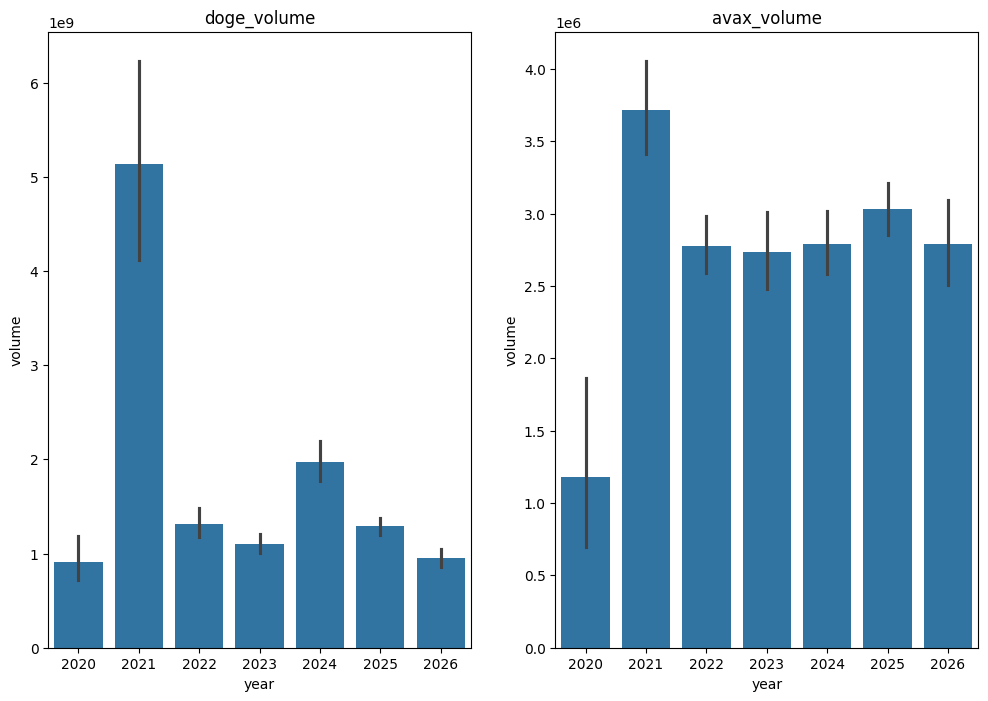

In [134]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
doge_price["year"]=doge_price["date"].dt.year
sns.barplot(x='year',data=doge_price,y='volume')
plt.title("doge_volume")
plt.subplot(1,2,2)
df2["year"]=df2["date"].dt.year
sns.barplot(x='year',data=avax_price,y='volume')
plt.title("avax_volume")
plt.show()

In [135]:
doge_price[['open','high','low','close','volume','quote_volume']].describe()

,open,high,low,close,volume,quote_volume
count,2209.000000,2209.000000,2209.000000,2209.000000,2.209000e+03,2.209000e+03
mean,0.129669,0.135736,0.123447,0.129709,1.947460e+09,3.130222e+08
std,0.099041,0.105694,0.092068,0.099003,4.797561e+09,8.757370e+08
min,0.001847,0.001882,0.001828,0.001850,5.534500e+07,1.029481e+05
25%,0.066690,0.069270,0.064370,0.066720,5.880606e+08,4.346036e+07
50%,0.100670,0.104340,0.096710,0.100660,9.771032e+08,1.060840e+08
75%,0.178100,0.184700,0.169870,0.178100,1.760795e+09,2.604496e+08
max,0.689820,0.739950,0.600000,0.689820,1.090737e+11,1.759856e+10


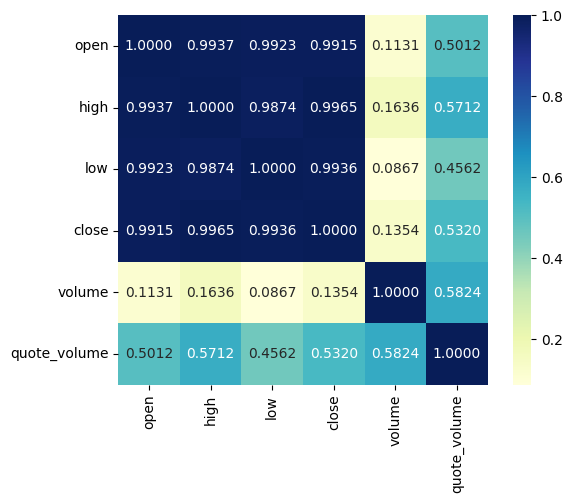

In [136]:
corr1=doge_price[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr1,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

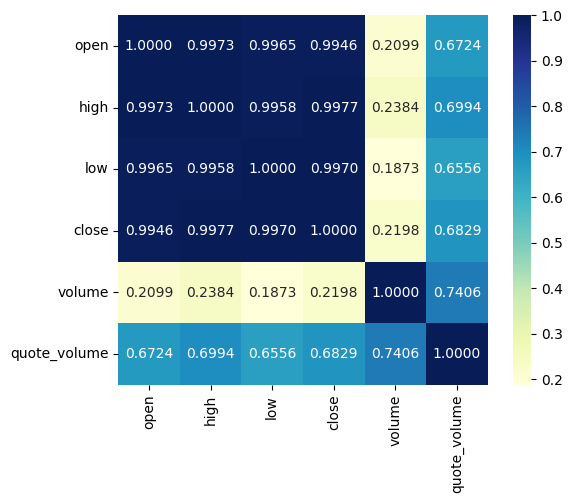

In [137]:
corr2=avax_price[['open','high','low','close','volume','quote_volume']].corr()
sns.heatmap(corr2,annot=True,square=True,fmt='.4f',cmap='YlGnBu')
plt.show()

In [138]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    doge_year = doge_price[doge_price['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=doge_year['date'],
        open=doge_year['open'],
        high=doge_year['high'],
        low=doge_year['low'],
        close=doge_year['close']
    )])

    fig.update_layout(title=f'Doge Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    doge_year = doge_price[doge_price['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=doge_year['date'],\n        open=doge_year['open'],\n        high=doge_year['high'],\n        low=doge_year['low'],\n        close=doge_year['close']\n    )])\n\n    fig.update_layout(title=f'Doge Chart - {year}')\n    fig.show()"

In [139]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    doge_filtered = doge_price[(doge_price['date'].dt.year == year) & (doge_price['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=doge_filtered['date'],
        open=doge_filtered['open'],
        high=doge_filtered['high'],
        low=doge_filtered['low'],
        close=doge_filtered['close']
    )])

    fig.update_layout(title=f'Doge Candlestick - {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    doge_filtered = doge_price[(doge_price['date'].dt.year == year) & (doge_price['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=doge_filtered['date'],\n        open=doge_filtered['open'],\n        high=doge_filtered['high'],\n        low=doge_filtered['low'],\n        close=doge_filtered['close']\n    )])\n\n    fig.update_layout(title=f'Doge Candlestick - {year} (Jan, Jun, Dec)')\n    fig.show()"

In [140]:
"""for year in [2020, 2021, 2022, 2023, 2024,2025]:
    avax_year = avax_price[avax_price['date'].dt.year == year]

    fig = go.Figure(data=[go.Candlestick(
        x=avax_year['date'],
        open=avax_year['open'],
        high=avax_year['high'],
        low=avax_year['low'],
        close=avax_year['close']
    )])

    fig.update_layout(title=f'Avex Chart - {year}')
    fig.show()"""

"for year in [2020, 2021, 2022, 2023, 2024,2025]:\n    avax_year = avax_price[avax_price['date'].dt.year == year]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=avax_year['date'],\n        open=avax_year['open'],\n        high=avax_year['high'],\n        low=avax_year['low'],\n        close=avax_year['close']\n    )])\n\n    fig.update_layout(title=f'Avex Chart - {year}')\n    fig.show()"

In [141]:
"""import plotly.graph_objects as go

years_months = {
    2020: [3, 8, 12],
    2021: [1, 4, 11],
    2022: [1, 5, 11],
    2023: [1, 3, 10],
    2024: [1, 3, 11],
}
for year, months in years_months.items():
    avax_filtered = avax_price[(avax_price['date'].dt.year == year) & (avax_price['date'].dt.month.isin(months))]

    fig = go.Figure(data=[go.Candlestick(
        x=avax_filtered['date'],
        open=avax_filtered['open'],
        high=avax_filtered['high'],
        low=avax_filtered['low'],
        close=avax_filtered['close']
    )])

    fig.update_layout(title=f'Avex- {year} (Jan, Jun, Dec)')
    fig.show()"""

"import plotly.graph_objects as go\n\nyears_months = {\n    2020: [3, 8, 12],\n    2021: [1, 4, 11],\n    2022: [1, 5, 11],\n    2023: [1, 3, 10],\n    2024: [1, 3, 11],\n}\nfor year, months in years_months.items():\n    avax_filtered = avax_price[(avax_price['date'].dt.year == year) & (avax_price['date'].dt.month.isin(months))]\n\n    fig = go.Figure(data=[go.Candlestick(\n        x=avax_filtered['date'],\n        open=avax_filtered['open'],\n        high=avax_filtered['high'],\n        low=avax_filtered['low'],\n        close=avax_filtered['close']\n    )])\n\n    fig.update_layout(title=f'Avex- {year} (Jan, Jun, Dec)')\n    fig.show()"

In [142]:
doge_price["candle_body"]=doge_price['close']-doge_price['open']
avax_price['candle_body']=avax_price['close']-avax_price['open']

In [143]:
doge_price['high_low_range']=doge_price['high']-doge_price['low']
avax_price['high_low_range']=avax_price['high']-avax_price['low']

In [144]:
doge_price['MA_7']=doge_price['close'].rolling(window=7).mean()
avax_price['MA_7']=avax_price['close'].rolling(window=7).mean()

In [145]:
doge_price['MA_30']=doge_price['close'].rolling(window=30).mean()
avax_price['MA_30']=avax_price['close'].rolling(window=30).mean()

In [146]:
doge_price['moving_1d']=(doge_price['close']-doge_price['close'].shift(1))/doge_price['close'].shift(1) * 100
avax_price['moving_1d']=(avax_price['close']-avax_price['close'].shift(1))/avax_price['close'].shift(1) * 100

In [147]:
doge_price["volatility_7"] = doge_price["moving_1d"].rolling(window=7).std()
avax_price["volatility_7"] = avax_price["moving_1d"].rolling(window=7).std()

In [148]:
doge_price["volume_MA7"] = doge_price["volume"].rolling(window=7).mean()
doge_price["volumelast7"] = doge_price["volume"] / doge_price["volume_MA7"]
avax_price["volume_MA7"] = avax_price["volume"].rolling(window=7).mean()
avax_price["volumelast7"] = avax_price["volume"] / avax_price["volume_MA7"]

In [149]:
doge_price.drop(columns='volume_MA7',inplace=True)
avax_price.drop(columns='volume_MA7',inplace=True)

In [150]:
doge_price["rolling_mean_30"] = doge_price["close"].rolling(window=30).mean()
doge_price["rolling_std_30"]  = doge_price["close"].rolling(window=30).std()
doge_price["z_score"] = (doge_price["close"] - doge_price["rolling_mean_30"]) / doge_price["rolling_std_30"]

avax_price["rolling_mean_30"] = avax_price["close"].rolling(window=30).mean()
avax_price["rolling_std_30"]  = avax_price["close"].rolling(window=30).std()
avax_price["z_score"] = (avax_price["close"] - avax_price["rolling_mean_30"]) / avax_price["rolling_std_30"]

In [151]:
doge_price.drop(columns='rolling_mean_30',inplace=True)
avax_price.drop(columns='rolling_mean_30',inplace=True)
doge_price.drop(columns='rolling_std_30',inplace=True)
avax_price.drop(columns='rolling_std_30',inplace=True)

In [152]:
doge_price['tomorrow_close'] = doge_price['close'].shift(-1)
doge_price['tomorrow_return'] = (doge_price['tomorrow_close'] - doge_price['close']) / doge_price['close'] * 100

avax_price['tomorrow_close'] = avax_price['close'].shift(-1)
avax_price['tomorrow_return'] = (avax_price['tomorrow_close'] - avax_price['close']) / avax_price['close'] * 100

In [153]:
doge_price.head()

,date,open,high,low,close,volume,quote_volume,type,year,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-04-04,0.001847,0.001909,0.001828,0.001870,92364705.0,171975.042374,DOGE,2020,0.000023,0.000081,NaN,NaN,NaN,NaN,NaN,NaN,0.001850,-1.053645
1,2020-04-05,0.001875,0.001882,0.001838,0.001850,55344996.0,102948.075591,DOGE,2020,-0.000024,0.000044,NaN,NaN,-1.053645,NaN,NaN,NaN,0.001990,7.545946
2,2020-04-06,0.001847,0.001990,0.001844,0.001990,210552139.0,404969.943854,DOGE,2020,0.000143,0.000146,NaN,NaN,7.545946,NaN,NaN,NaN,0.001994,0.236228
3,2020-04-07,0.001989,0.002021,0.001950,0.001994,202961221.0,404348.051512,DOGE,2020,0.000005,0.000071,NaN,NaN,0.236228,NaN,NaN,NaN,0.002004,0.476358
4,2020-04-08,0.001997,0.002043,0.001967,0.002004,90384907.0,181433.658845,DOGE,2020,0.000007,0.000076,NaN,NaN,0.476358,NaN,NaN,NaN,0.002015,0.563929


In [154]:
from scipy.stats import skew, kurtosis
doge_price = doge_price.dropna(subset=['tomorrow_return'])
skew2=skew(doge_price['tomorrow_return'])
print(skew2)

avax_price = avax_price.dropna(subset=['tomorrow_return'])
skew21=skew(avax_price['tomorrow_return'])
print(skew21)

kurtosis1=kurtosis(doge_price['tomorrow_return'])
kurtosis2=kurtosis(avax_price['tomorrow_return'])
kurtosis1,kurtosis2

23.55136092299451
1.1852987357585787


(np.float64(841.6338695059057), np.float64(12.824750844285232))

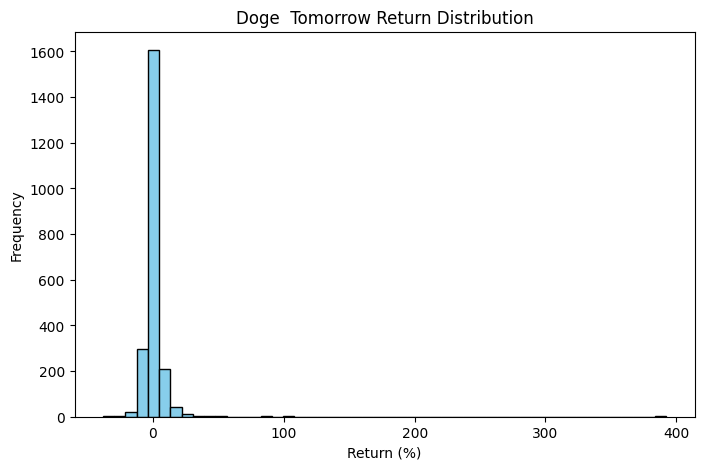

In [155]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(doge_price['tomorrow_return'], bins=50, color='skyblue', edgecolor='black')
plt.title('Doge  Tomorrow Return Distribution')
plt.xlabel('Return (%)')
plt.ylabel('Frequency')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_10280\621904504.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(doge_price['tomorrow_return'], shade=True, color='orange')


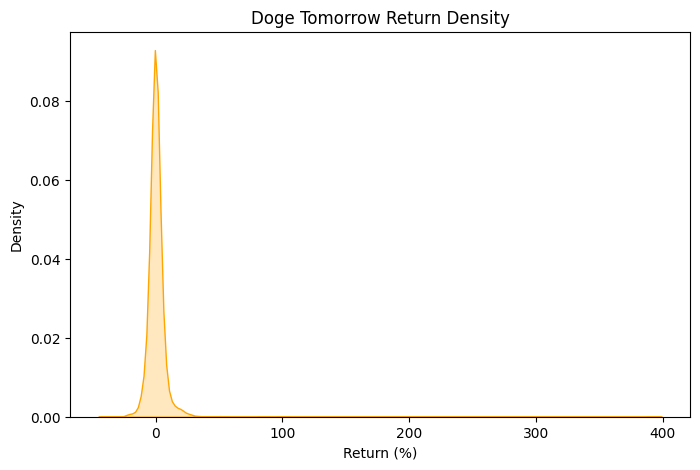

In [156]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.kdeplot(doge_price['tomorrow_return'], shade=True, color='orange')
plt.title('Doge Tomorrow Return Density')
plt.xlabel('Return (%)')
plt.show()

C:\Users\ibrah\AppData\Local\Temp\ipykernel_10280\2731056094.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(doge_price['tomorrow_return'], shade=True, color='lightblue')


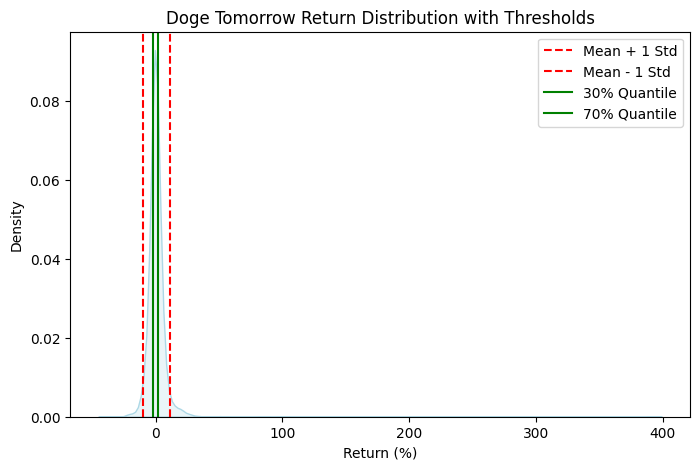

In [157]:
mean = doge_price['tomorrow_return'].mean()
std = doge_price['tomorrow_return'].std()
q_low = doge_price['tomorrow_return'].quantile(0.3)
q_high = doge_price['tomorrow_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(doge_price['tomorrow_return'], shade=True, color='lightblue')

plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('Doge Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

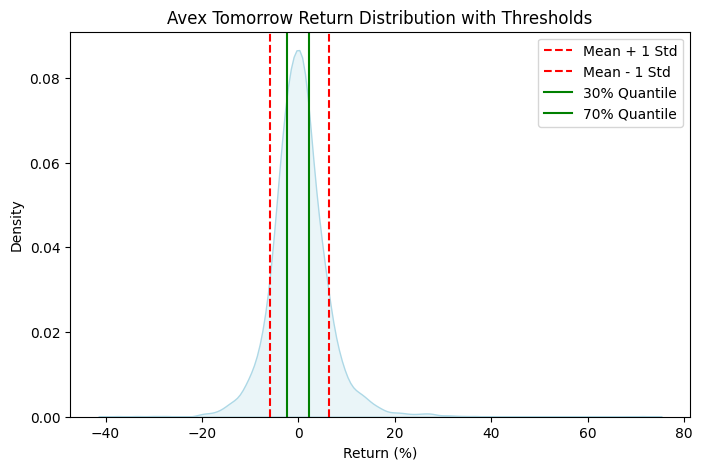

In [158]:

mean = avax_price['tomorrow_return'].mean()
std = avax_price['tomorrow_return'].std()
q_low = avax_price['tomorrow_return'].quantile(0.3)
q_high = avax_price['tomorrow_return'].quantile(0.7)

plt.figure(figsize=(8,5))
sns.kdeplot(avax_price['tomorrow_return'], fill=True, color='lightblue')

# Mean ± std thresholds
plt.axvline(mean + std, color='red', linestyle='--', label='Mean + 1 Std')
plt.axvline(mean - std, color='red', linestyle='--', label='Mean - 1 Std')

# Quantile thresholds
plt.axvline(q_low, color='green', linestyle='-', label='30% Quantile')
plt.axvline(q_high, color='green', linestyle='-', label='70% Quantile')

plt.title('Avex Tomorrow Return Distribution with Thresholds')
plt.xlabel('Return (%)')
plt.legend()
plt.show()

In [159]:
doge_price[30:35]

,date,open,high,low,close,volume,quote_volume,type,year,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
30,2020-05-04,0.002501,0.002509,0.002338,0.002461,151515338.0,368279.210588,DOGE,2020,-0.000041,0.000172,0.002461,0.002126,-1.583937,3.358159,0.601660,1.524202,0.002474,0.540541
31,2020-05-05,0.002472,0.002518,0.002427,0.002474,83336304.0,205477.629148,DOGE,2020,0.000002,0.000092,0.002482,0.002147,0.540541,3.294411,0.347674,1.473572,0.002480,0.254669
32,2020-05-06,0.002478,0.002562,0.002457,0.002480,180927494.0,453917.833249,DOGE,2020,0.000002,0.000105,0.002481,0.002164,0.254669,1.885947,0.842092,1.390685,0.002663,7.362606
33,2020-05-07,0.002480,0.002697,0.002459,0.002663,366483103.0,948174.828038,DOGE,2020,0.000183,0.000238,0.002513,0.002186,7.362606,3.098238,1.945475,1.964978,0.002605,-2.159462
34,2020-05-08,0.002663,0.002689,0.002570,0.002605,259386572.0,677557.147905,DOGE,2020,-0.000058,0.000119,0.002532,0.002206,-2.159462,3.354572,1.337244,1.585873,0.002608,0.088285


In [160]:
doge_price.isna().sum()

date                0
open                0
high                0
low                 0
close               0
volume              0
quote_volume        0
type                0
year                0
candle_body         0
high_low_range      0
MA_7                6
MA_30              29
moving_1d           1
volatility_7        7
volumelast7         6
z_score            29
tomorrow_close      0
tomorrow_return     0
dtype: int64

In [161]:
doge_price.dropna(inplace=True)
avax_price.dropna(inplace=True)

In [162]:
doge_price.reset_index(drop=True,inplace=True)
avax_price.reset_index(drop=True,inplace=True)

In [163]:
doge_price.drop(columns='year',axis=1,inplace=True)

In [164]:
avax_price.head()

,date,open,high,low,close,volume,quote_volume,type,year,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-10-21,3.8007,4.1030,3.7918,3.9585,319446.86,1.268228e+06,AVAX,2020,0.1578,0.3112,4.042400,4.156193,4.061514,3.540146,0.921982,-0.521106,4.3385,9.599596
1,2020-10-22,3.9574,4.4904,3.9511,4.3385,741499.28,3.221997e+06,AVAX,2020,0.3811,0.5393,4.072629,4.123500,9.599596,5.241690,1.814665,0.689205,4.2568,-1.883139
2,2020-10-23,4.3406,4.4872,4.1354,4.2568,324892.94,1.399000e+06,AVAX,2020,-0.0838,0.3518,4.103129,4.147560,-1.883139,5.228994,0.859134,0.373841,4.1821,-1.754839
3,2020-10-24,4.2539,4.3620,4.1400,4.1821,218601.98,9.333386e+05,AVAX,2020,-0.0718,0.2220,4.101343,4.132260,-1.754839,5.134657,0.586939,0.179861,4.1479,-0.817771
4,2020-10-25,4.1803,4.2526,4.1000,4.1479,209663.90,8.770354e+05,AVAX,2020,-0.0324,0.1526,4.105400,4.113410,-0.817771,5.088963,0.547941,0.135509,4.1480,0.002411


In [165]:
doge_price.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-05-03,0.002539,0.002580,0.002460,0.002500,167590125.0,420950.854319,DOGE,-0.000039,0.000120,0.002445,0.002107,-1.648308,3.490418,0.562216,1.832843,0.002461,-1.583937
1,2020-05-04,0.002501,0.002509,0.002338,0.002461,151515338.0,368279.210588,DOGE,-0.000041,0.000172,0.002461,0.002126,-1.583937,3.358159,0.601660,1.524202,0.002474,0.540541
2,2020-05-05,0.002472,0.002518,0.002427,0.002474,83336304.0,205477.629148,DOGE,0.000002,0.000092,0.002482,0.002147,0.540541,3.294411,0.347674,1.473572,0.002480,0.254669
3,2020-05-06,0.002478,0.002562,0.002457,0.002480,180927494.0,453917.833249,DOGE,0.000002,0.000105,0.002481,0.002164,0.254669,1.885947,0.842092,1.390685,0.002663,7.362606
4,2020-05-07,0.002480,0.002697,0.002459,0.002663,366483103.0,948174.828038,DOGE,0.000183,0.000238,0.002513,0.002186,7.362606,3.098238,1.945475,1.964978,0.002605,-2.159462


In [166]:
avax_price.drop("year",axis=1,inplace=True)

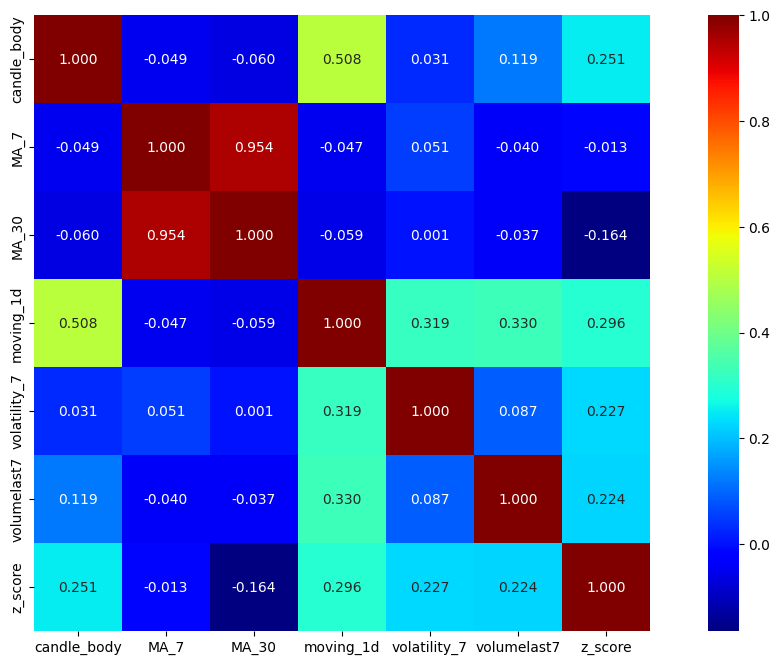

In [167]:
plt.figure(figsize=(15,8))
corr8=doge_price[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr8,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

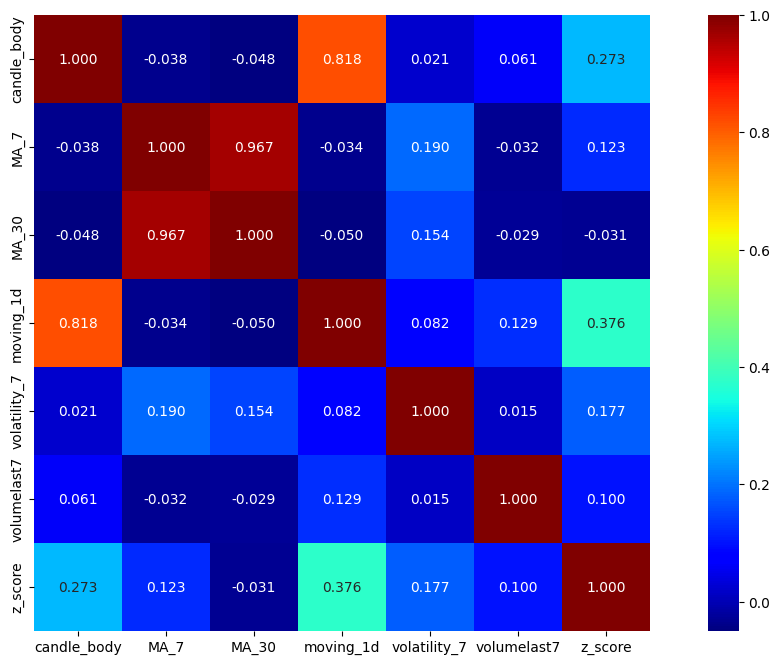

In [168]:
plt.figure(figsize=(15,8))
corr9=avax_price[['candle_body','MA_7','MA_30','moving_1d','volatility_7','volumelast7','z_score']].corr()
sns.heatmap(corr9,annot=True,square=True,cmap='jet',fmt='0.3f')
plt.show()

In [169]:
combined=pd.concat([doge_price,avax_price],ignore_index=True)
combined.to_csv("avax_dodge_6years_binance.csv",index=False)

In [170]:
df9=pd.read_csv("avax_dodge_6years_binance.csv")

In [171]:
df9.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-05-03,0.002539,0.002580,0.002460,0.002500,167590125.0,420950.854319,DOGE,-0.000039,0.000120,0.002445,0.002107,-1.648308,3.490418,0.562216,1.832843,0.002461,-1.583937
1,2020-05-04,0.002501,0.002509,0.002338,0.002461,151515338.0,368279.210588,DOGE,-0.000041,0.000172,0.002461,0.002126,-1.583937,3.358159,0.601660,1.524202,0.002474,0.540541
2,2020-05-05,0.002472,0.002518,0.002427,0.002474,83336304.0,205477.629148,DOGE,0.000002,0.000092,0.002482,0.002147,0.540541,3.294411,0.347674,1.473572,0.002480,0.254669
3,2020-05-06,0.002478,0.002562,0.002457,0.002480,180927494.0,453917.833249,DOGE,0.000002,0.000105,0.002481,0.002164,0.254669,1.885947,0.842092,1.390685,0.002663,7.362606
4,2020-05-07,0.002480,0.002697,0.002459,0.002663,366483103.0,948174.828038,DOGE,0.000183,0.000238,0.002513,0.002186,7.362606,3.098238,1.945475,1.964978,0.002605,-2.159462


In [172]:
df9.shape

(4187, 18)

In [173]:

df7.shape

(2008, 18)

In [174]:
combined_final=pd.concat([df3,df4,df5,df6,df7,df9],ignore_index=True)
combined_final.to_csv("final_crypto.csv",index=False)

In [175]:
df10=pd.read_csv("final_crypto.csv")

In [176]:
df10.head()

,date,open,high,low,close,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,tomorrow_close,tomorrow_return
0,2020-04-20,7121.40,7220.00,6751.0,6826.83,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665,6841.37,0.212983
1,2020-04-21,6828.98,6940.00,6762.0,6841.37,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,7125.14,4.147853
2,2020-04-22,6841.36,7156.38,6818.0,7125.14,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,7482.39,5.013937
3,2020-04-23,7125.12,7738.00,7020.0,7482.39,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,7505.00,0.302176
4,2020-04-24,7483.96,7615.96,7388.0,7505.00,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,7538.67,0.448634


In [177]:
df10.shape

(17004, 18)

In [178]:
#df10.drop("year",axis=1,inplace=True)

In [179]:
df10.shape

(17004, 18)

In [180]:
df10["type"].value_counts()

type
BTC     2192
ETH     2192
BNB     2189
XRP     2186
DOGE    2179
SOL     2050
ADA     2008
AVAX    2008
Name: count, dtype: int64

In [181]:
df10.isna().sum()

date               0
open               0
high               0
low                0
close              0
volume             0
quote_volume       0
type               0
candle_body        0
high_low_range     0
MA_7               0
MA_30              0
moving_1d          0
volatility_7       0
volumelast7        0
z_score            0
tomorrow_close     0
tomorrow_return    0
dtype: int64

In [182]:
q_low  = df10['tomorrow_return'].quantile(0.30)
q_high = df10['tomorrow_return'].quantile(0.70)

print(f"Global lower: {q_low:.2f}%")
print(f"Global upper: {q_high:.2f}%")

# apply to all coins
def label(r):
    if r > q_high:       return 'Bigup'
    elif r < q_low:      return 'Bigdown'
    elif pd.notnull(r):  return 'Stable'
    else:                return None

df10['target'] = df10['tomorrow_return'].apply(label)



Global lower: -1.61%
Global upper: 1.64%


In [183]:

print("\nDistribution per coin:")
print(df10.groupby('type')['target'].value_counts())


Distribution per coin:
type  target 
ADA   Bigdown     736
      Bigup       693
      Stable      579
AVAX  Bigdown     736
      Bigup       693
      Stable      579
BNB   Stable     1092
      Bigup       584
      Bigdown     513
BTC   Stable     1224
      Bigup       511
      Bigdown     457
DOGE  Stable      829
      Bigdown     710
      Bigup       640
ETH   Stable      953
      Bigup       651
      Bigdown     588
SOL   Bigdown     731
      Bigup       715
      Stable      604
XRP   Stable      942
      Bigdown     630
      Bigup       614
Name: count, dtype: int64


In [184]:
df10["target"].value_counts()

target
Stable     6802
Bigup      5101
Bigdown    5101
Name: count, dtype: int64

In [185]:
pd.crosstab(df10["type"], df10["target"], normalize="index")

target,Bigdown,Bigup,Stable
type,,,
ADA,0.366534,0.345120,0.288347
AVAX,0.366534,0.345120,0.288347
BNB,0.234354,0.266788,0.498858
BTC,0.208485,0.233120,0.558394
DOGE,0.325838,0.293713,0.380450
ETH,0.268248,0.296989,0.434763
SOL,0.356585,0.348780,0.294634
XRP,0.288198,0.280878,0.430924


In [186]:
df10.drop(["tomorrow_close",
"tomorrow_return" ,"open","high","low","close"],axis=1,inplace=True)

In [187]:
df10.head()

,date,volume,quote_volume,type,candle_body,high_low_range,MA_7,MA_30,moving_1d,volatility_7,volumelast7,z_score,target
0,2020-04-20,90149.491370,6.296124e+08,BTC,-294.57,469.00,6973.657143,6766.366000,-4.127520,4.021079,1.274637,0.157665,Stable
1,2020-04-21,60109.710808,4.118006e+08,BTC,12.39,178.00,6969.752857,6800.538667,0.212983,4.018091,0.865563,0.120445,Bigup
2,2020-04-22,61486.377334,4.312716e+08,BTC,283.78,338.38,7041.738571,6822.466333,4.147853,3.923088,0.885542,0.895536,Bigup
3,2020-04-23,102773.569561,7.563202e+08,BTC,357.27,718.00,7096.088571,6847.055333,5.013937,3.393093,1.551135,1.772948,Stable
4,2020-04-24,60182.119939,4.521181e+08,BTC,21.04,227.96,7164.295714,6874.641000,0.302176,3.308075,0.896607,1.675384,Stable
